# SalesData EDA Process,Analysis & Feature Engineering
#### 1. Missing Values
#### 2. Explore About The Numerical Variable
#### 3. Explore Categorical variable(how may categories are there)
#### 4. Finding Relationships between features

In [1]:
import pandas as pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statistics
from scipy.stats import entropy
from difflib import SequenceMatcher
from scipy import stats
import math

In [2]:
sales = pandas.read_csv("../eabl parsed csv/eabl_sales_consolidated.csv")
sales

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153283,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Mis Plastic Container Ever,3.00,3
1153284,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Complete - M/P Amber In Lps,2.00,2
1153285,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Complete - M/P Ren Flint In Lps,2.00,2
1153286,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaN,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,1.00,0


# Sales Data Eda
#### 1. Missing Values
#### 2. Explore About The Numerical Vriable
#### 3. Explore Categorical variable(how may categories are there)
#### 4. Finding Relationships between features

## 1. Missing Values

In [3]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1153288 entries, 0 to 1153287
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   source_file      1153288 non-null  str    
 1   salesperson      1153288 non-null  str    
 2   customer_code    1153288 non-null  str    
 3   cust_type        1153288 non-null  str    
 4   segment          1153286 non-null  str    
 5   visit_date       993617 non-null   str    
 6   product          1153288 non-null  str    
 7   quantity         1153288 non-null  float64
 8   return_quantity  1153288 non-null  int64  
dtypes: float64(1), int64(1), str(7)
memory usage: 212.7 MB


In [4]:
sales.describe()

,quantity,return_quantity
count,1.153288e+06,1.153288e+06
mean,2.693060e+01,1.594696e+00
std,4.445434e+02,1.570681e+01
min,-9.761000e+01,0.000000e+00
25%,1.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00
75%,1.000000e+01,0.000000e+00
max,4.000000e+05,9.940000e+02


In [5]:
print(sales.shape)

(1153288, 9)


<Axes: >

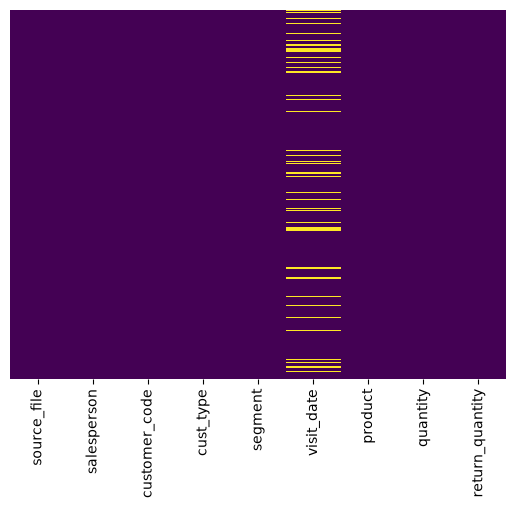

In [6]:
sns.heatmap(sales.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [7]:
sales.isnull().sum()

source_file             0
salesperson             0
customer_code           0
cust_type               0
segment                 2
visit_date         159671
product                 0
quantity                0
return_quantity         0
dtype: int64

### a)Fix visit_date Missing Data and datatype

In [8]:
sales["visit_date"] = pandas.to_datetime(sales["visit_date"], format="%Y-%m-%d", errors="coerce")

In [9]:
sales.dtypes

source_file                   str
salesperson                   str
customer_code                 str
cust_type                     str
segment                       str
visit_date         datetime64[us]
product                       str
quantity                  float64
return_quantity             int64
dtype: object

In [10]:
sales["visit_date"].isnull().sum()

np.int64(159671)

In [11]:
sales["visit_date"].dtype

dtype('<M8[us]')

In [12]:
sales.dtypes

source_file                   str
salesperson                   str
customer_code                 str
cust_type                     str
segment                       str
visit_date         datetime64[us]
product                       str
quantity                  float64
return_quantity             int64
dtype: object

Mean visit date:   2025-11-19
Median visit date: 2025-11-24
Mode visit date:   2025-12-24  (4854 rows on that day)


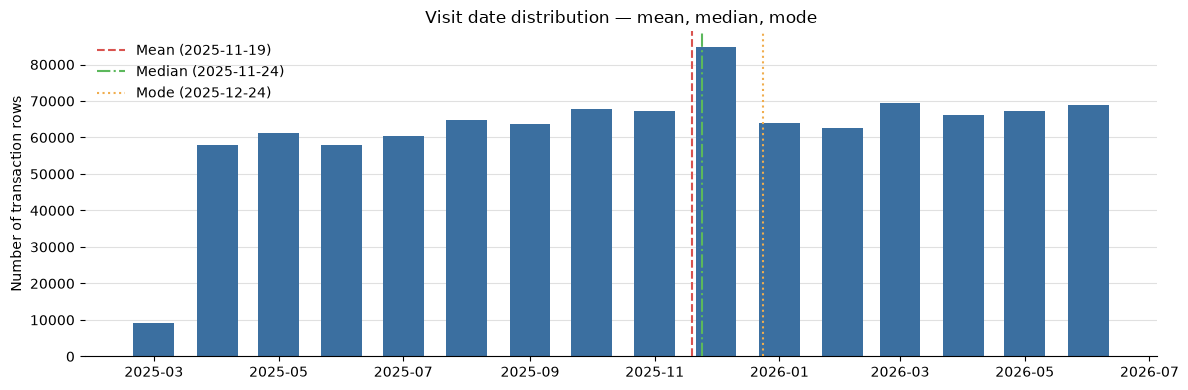

In [13]:
# --- compute the three statistics ---
mean_date = sales["visit_date"].mean()
median_date = sales["visit_date"].median()
mode_date = sales["visit_date"].mode()[0]  # busiest single day; [0] handles ties

print(f"Mean visit date:   {mean_date.date()}")
print(f"Median visit date: {median_date.date()}")
print(f"Mode visit date:   {mode_date.date()}  ({(sales['visit_date'] == mode_date).sum()} rows on that day)")

# --- plot: monthly distribution with mean/median/mode marked ---
import matplotlib.pyplot as plt

monthly_counts = sales["visit_date"].dt.to_period("M").value_counts().sort_index()
monthly_counts.index = monthly_counts.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly_counts.index, monthly_counts.values, width=20, color="#3B6FA0", zorder=2)

ax.axvline(mean_date, color="#D9534F", linestyle="--", linewidth=1.5, zorder=3, label=f"Mean ({mean_date.date()})")
ax.axvline(median_date, color="#5CB85C", linestyle="-.", linewidth=1.5, zorder=3, label=f"Median ({median_date.date()})")
ax.axvline(mode_date, color="#F0AD4E", linestyle=":", linewidth=1.5, zorder=3, label=f"Mode ({mode_date.date()})")

ax.set_title("Visit date distribution — mean, median, mode")
ax.set_ylabel("Number of transaction rows")
ax.grid(axis="y", color="#e0e0e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()



In [14]:
col = "visit_date"  

null_mask = sales[col].isna()
sales.loc[null_mask]


,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
2497,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Total,Cash,Specialist Store,NaT,Smrnf Red 25Cl 40X01 Reggie,67.00,0
2498,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Total,Cash,Specialist Store,NaT,Guinness (K) Per Bottle,16.36,0
2499,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Total,Cash,Specialist Store,NaT,Multipurpose Amber 300ml,214.00,214
2500,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Total,Cash,Specialist Store,NaT,Tusker In Can 500ml CAN 24X01*,6.50,0
2501,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,Total,Cash,Specialist Store,NaT,Gilbeys Gin 25Cl 40X01,111.00,0
...,...,...,...,...,...,...,...,...,...
1153283,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Mis Plastic Container Ever,3.00,3
1153284,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Complete - M/P Amber In Lps,2.00,2
1153285,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Complete - M/P Ren Flint In Lps,2.00,2
1153286,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,Van closing Stock,Cash,Event,NaT,Smirnoff Cosmopolitan Cocktail 75cl 10Y 12X01,1.00,0


In [15]:
missing_date_rows = sales[sales["visit_date"].isna()]
print(f"Rows with missing visit_date: {len(missing_date_rows)}")
print()

for col in [c for c in sales.columns if c != "visit_date"]:
    print(f"--- most common values of '{col}' among missing-date rows ---")
    print(missing_date_rows[col].value_counts().head(10))
    print()


Rows with missing visit_date: 159671

--- most common values of 'source_file' among missing-date rows ---
source_file
DailySalesReportNew_0105202510052025.xlsx    5885
DailySalesReportNew_1604202530042025.xlsx    5614
DailySalesReportNew_1612202531122025.xlsx    5508
DailySalesReportNew_1607202531072025.xlsx    5470
DailySalesReportNew_0104202515042025.xlsx    5429
DailySalesReportNew_1105202531062025.xlsx    5422
DailySalesReportNew_0106202515062025.xlsx    5295
DailySalesReportNew_0112202515122025.xlsx    5281
DailySalesReportNew_1608202531082025.xlsx    5267
DailySalesReportNew_0103202505032025.xlsx    5257
Name: count, dtype: int64

--- most common values of 'salesperson' among missing-date rows ---
salesperson
TONY MULEI-LANET              14623
ELISHA MARWA-TOWN B           14617
JOHN MWANGI-CBD               14048
JOSPHAT ONDIGO-PIPELINE       13683
SEBASTIAN MUKHANZI-GILGIL     13539
ERASTUS LIMO-BAHATIHESHIMA    12517
JOSEPH MWANIKI-KANU           12359
VINCENT MUSERA-OLK ROUT

In [166]:
sales

### Dropping of missing Data due to finding out they are invalid rows

In [16]:
sales = sales.dropna(subset=["visit_date"])

In [17]:
sales.isnull().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            2
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

### b)Fix Segment Missing Data and Imputed with the Mode

In [18]:
col2 = "segment"  

null_mask = sales[col2].isna()
sales.loc[null_mask]


,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
815724,DailySalesReportNew_1606202530062025.xlsx,Marvin Odhiambo,KE0061568,Credit,NaN,2025-06-17,Liberty Potable Brown Spirit 25cl 40X01,2.0,0
815725,DailySalesReportNew_1606202530062025.xlsx,Marvin Odhiambo,KE0061568,Credit,NaN,2025-06-17,Kenya Cane Lemon & Ginger 25cl 40X01,2.0,0


In [19]:
segment_cat = sales["segment"].astype("category")
codes = segment_cat.cat.codes  # each category mapped to an integer, alphabetical order by default

print("Mode:  ", sales["segment"].mode()[0])
print("Median:", codes.median(), f"-> category: {segment_cat.cat.categories[int(codes.median())]}")

Mode:   Bar
Median: 2.0 -> category: Event


In [20]:
col = "segment"  # change to whichever column

print(f"Number of unique values: {sales[col].nunique()}")
print()

print("Unique values:")
print(sales[col].unique())
print()

print("Mode (most frequent value):")
print(sales[col].mode())
print()

print("Frequency of every unique value (mode is just the top row here):")
print(sales[col].value_counts())


Number of unique values: 12

Unique values:
<ArrowStringArray>
[             'Bar', 'Specialist Store',       'Wholesaler',
       'Restaurant',          'Lodging',            'Event',
        'Nightclub',      'Supermarket',       'Recreation',
      'Marketplace',      'Convenience',   'Not Applicable',
                nan]
Length: 13, dtype: str

Mode (most frequent value):
0    Bar
Name: segment, dtype: str

Frequency of every unique value (mode is just the top row here):
segment
Bar                 483786
Specialist Store    401325
Wholesaler           35281
Event                20115
Lodging              14638
Nightclub            13448
Restaurant            7298
Marketplace           6579
Supermarket           5353
Recreation            3624
Convenience           2132
Not Applicable          36
Name: count, dtype: int64


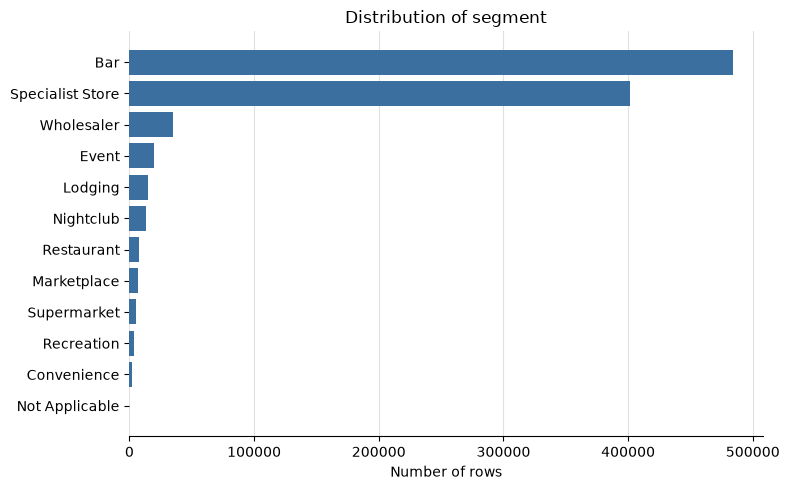

In [21]:
import matplotlib.pyplot as plt

segment_counts = sales["segment"].value_counts().sort_values(ascending=True)  # ascending so the largest bar ends up on top

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(segment_counts.index, segment_counts.values, color="#3B6FA0", zorder=2)

ax.set_title("Distribution of segment")
ax.set_xlabel("Number of rows")
ax.grid(axis="x", color="#e0e0e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


In [22]:
sales["segment"] = sales["segment"].fillna("Bar")
sales.isna().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            0
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

# Check for unique values in the customer_code column

In [23]:
sales["customer_code"].value_counts().head(1000000)

customer_code
KE0159054    14647
KE0120507    12330
KE0134393     7317
KE0120509     6870
KE0071094     6276
             ...  
KE0142046        2
KE0062268        1
KE0062000        1
KE0062278        1
KE0171004        1
Name: count, Length: 948, dtype: int64

# Van Opening Stock Inspection


In [24]:
sales.loc[sales["customer_code"].isin(["Van opening Stock"])]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity


In [25]:
sales.loc[
    (sales["customer_code"].isin(["Van opening Stock"])) &
    (sales["visit_date"].isna())
]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity


#### Find the Sum of the unique value Van Opening Stock whose dates are NaT

In [26]:
(
    (sales["customer_code"].isin(["Van opening Stock"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(0)

# Van Closing Stock Inspection

In [27]:
sales.loc[sales["customer_code"].isin(["Van closing Stock"])]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity


In [28]:
sales.loc[
    (sales["customer_code"].isin(["Van closing Stock"])) &
    (sales["visit_date"].isna())
]

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity


### Find the Sum of the unique value Van Closing Stock whose dates are NaT

In [29]:
(
    (sales["customer_code"].isin(["Van closing Stock"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(0)

## Sales Quantity Unique Value Inspection to Find the sum of visit_date which are NaT

In [30]:
(
    (sales["customer_code"].isin(["Sales Quantity"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(0)

In [31]:
(
    (sales["customer_code"].isin(["Total"])) &
    (sales["visit_date"].isna())
).sum()

np.int64(0)

# Removing of NaT visit_date value rows since they are equally liked to the following:
### Total                46666
### Sales Quantity       42669
### Van closing Stock    41785
### Van opening Stock    34892
## Which are not actual customer codes

# Salesperson Inspection

In [32]:
sales["salesperson"].value_counts().head(1000000)

salesperson
ELISHA MARWA-TOWN B              109644
JOSPHAT ONDIGO-PIPELINE           95805
TONY MULEI-LANET                  93140
JOHN MWANGI-CBD                   91564
VINCENT MUSERA-OLK ROUTE          91258
KEY ACCOUNT                       86609
ERASTUS LIMO-BAHATIHESHIMA        83771
JOEL MAINA MWAURA-UDV VAN         73772
JOSEPH MWANIKI-KANU               72516
SEBASTIAN MUKHANZI-GILGIL         68340
ERIC KIAMA -OLK COUNTER           61552
WELDON KIRUI - NDUNDORI ROUTE     56837
Marvin Odhiambo                    3550
Vivian Jebiwott Yatich             2917
Martha  Mwende                     1190
Clare Wanyaga                       449
Barbara Mwatu                       302
Dennis Mutai                        138
Patrick Mukuna                      110
Evans Odero                          74
Norween  Kimalit                     41
Patricia Kinuthia                    26
Valentine Irungu                     12
Name: count, dtype: int64

# cust_type Inspection

In [33]:
sales["cust_type"].value_counts().head(1000000)

cust_type
Cash      902227
Credit     91390
Name: count, dtype: int64

# Segment Inspection

In [34]:
sales["segment"].value_counts().head(1000000)

segment
Bar                 483788
Specialist Store    401325
Wholesaler           35281
Event                20115
Lodging              14638
Nightclub            13448
Restaurant            7298
Marketplace           6579
Supermarket           5353
Recreation            3624
Convenience           2132
Not Applicable          36
Name: count, dtype: int64

In [35]:
sales["product"].value_counts().head(1000000)

product
Euroform Amber Local 500ml               57490
Smirldb&Guarana 330ml Can 24X01          42613
Kenya Cane Lemon & Ginger 25cl 40X01     35657
Smirnf Ice PP R 330ml CAN 24X01 local    34298
Kenya Cane Pneap 25cl 40X01              32161
                                         ...  
Complete - Mop up empties                    1
Manyatta Sweet Cider 300ml 06X04 BBIC        1
Ciroc Red Berry 70cl      06X01              1
Singleton of Dufftown 70cl 21Y 04X01         1
JW GOT SngOfIce 1L 12X01 GOT                 1
Name: count, Length: 259, dtype: int64

In [36]:
sales["quantity"].value_counts().head(100)

quantity
1.00      213680
2.00      111622
3.00       64897
5.00       64610
0.04       62645
           ...  
150.00       124
42.00        118
84.00        118
0.88         113
0.92         109
Name: count, Length: 100, dtype: int64

# Will need normalization later

In [37]:
sales["quantity"].describe()

count    993617.000000
mean         13.366132
std         471.931426
min         -48.000000
25%           0.600000
50%           2.000000
75%           5.000000
max      400000.000000
Name: quantity, dtype: float64

In [38]:
print("skew:", sales["quantity"].skew())
print("rows where quantity <= 0:", (sales["quantity"] <= 0).sum())
print("99th percentile:", sales["quantity"].quantile(0.99))

skew: 650.0444634088283
rows where quantity <= 0: 99
99th percentile: 200.0


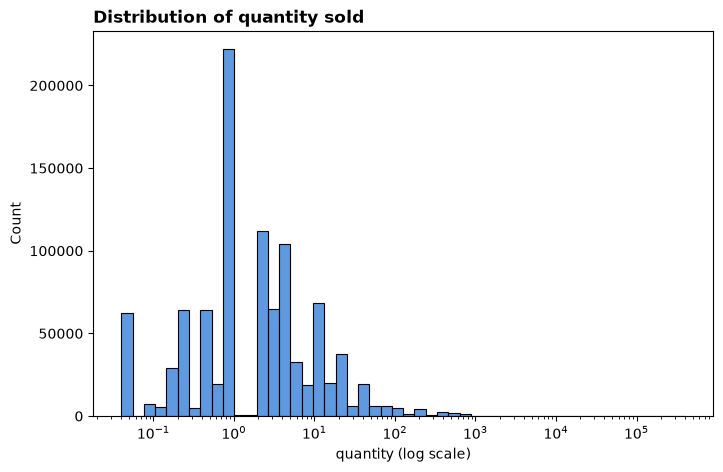

In [39]:
positive_qty = sales.loc[sales["quantity"] > 0, "quantity"]

plt.figure(figsize=(8, 5))
sns.histplot(positive_qty, bins=50, log_scale=True, color="#2a78d6")
plt.xlabel("quantity (log scale)")
plt.title("Distribution of quantity sold", loc="left", fontsize=12, fontweight="bold")
plt.show()

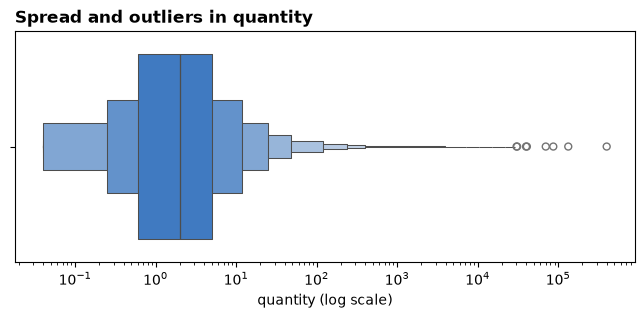

In [40]:
plt.figure(figsize=(8, 3))
sns.boxenplot(x=positive_qty, color="#2a78d6")
plt.xscale("log")
plt.xlabel("quantity (log scale)")
plt.title("Spread and outliers in quantity", loc="left", fontsize=12, fontweight="bold")
plt.show()

In [41]:
sales.isnull().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            0
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

In [42]:
sales["segment"] = sales["segment"].fillna("Bar")

In [43]:
sales[sales["segment"].isnull()]


,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity


In [44]:
sales

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0


In [45]:
sales.isnull().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            0
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

# 2. Sales Data Explore About The Numerical Variable and  Outlier Treatment and 

In [46]:
sales

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0


In [47]:
sales[["quantity", "return_quantity"]].describe()

,quantity,return_quantity
count,993617.000000,993617.000000
mean,13.366132,1.044747
std,471.931426,5.503525
min,-48.000000,0.000000
25%,0.600000,0.000000
50%,2.000000,0.000000
75%,5.000000,0.000000
max,400000.000000,475.000000


In [48]:
has_return = sales["return_quantity"] > 0
print(f"{has_return.sum()} rows have any return ({has_return.mean():.2%})")

# now look at the shape only among rows that actually have a return
sales.loc[has_return, "return_quantity"].describe()


112396 rows have any return (11.31%)


count    112396.000000
mean          9.235898
std          13.860429
min           1.000000
25%           1.000000
50%           3.000000
75%          12.000000
max         475.000000
Name: return_quantity, dtype: float64

## Outlier Detection Function

In [49]:
def find_anomalies(data):
    anomalies = []

    random_data_std = statistics.stdev(data)
    random_data_mean = statistics.mean(data)

    anomaly_cut_off = random_data_std * 3

    lower_limit = random_data_mean - anomaly_cut_off
    upper_limit = random_data_mean + anomaly_cut_off

    for outlier in data:
        if outlier > upper_limit or outlier < lower_limit:
            anomalies.append(outlier)
    return anomalies

In [50]:
 sales.quantity

0          7.00
1          0.28
2          1.00
3          2.00
4          0.60
           ... 
1153191    2.00
1153192    1.00
1153193    2.00
1153194    3.00
1153195    0.50
Name: quantity, Length: 993617, dtype: float64

In [51]:
list_1 = find_anomalies(sales['quantity'])

In [52]:
len(list_1)

476

In [53]:
len(sales)

993617

In [54]:
 sales.quantity.skew()

np.float64(650.0444634088283)

<Axes: xlabel='quantity', ylabel='Density'>

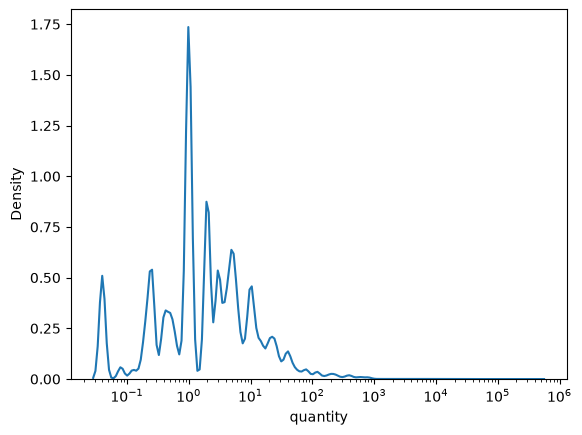

In [55]:
sns.kdeplot(sales.loc[sales["quantity"] > 0, "quantity"], log_scale=True)


In [56]:
sales["product"].nunique()


259

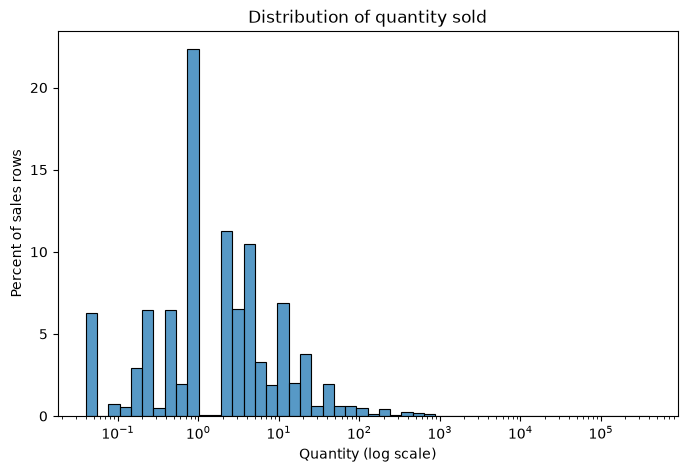

In [57]:
plt.figure(figsize=(8, 5))
sns.histplot(
    sales.loc[sales["quantity"] > 0, "quantity"],
    bins=50, log_scale=True, stat="percent"
)
plt.ylabel("Percent of sales rows")
plt.xlabel("Quantity (log scale)")
plt.title("Distribution of quantity sold")
plt.show()


In [58]:
positive_qty = sales.loc[sales["quantity"] > 0, "quantity"]

# build bin edges at each power of 10 spanning the data's actual range
min_exp = math.floor(np.log10(positive_qty.min()))
max_exp = math.ceil(np.log10(positive_qty.max()))
bin_edges = [10**e for e in range(min_exp, max_exp + 1)]
labels = [f"{bin_edges[i]:,.2g}–{bin_edges[i+1]:,.2g}" for i in range(len(bin_edges) - 1)]

binned = pandas.cut(positive_qty, bins=bin_edges, labels=labels, right=False)

quantity_table = binned.value_counts(sort=False).rename("rows").to_frame()
quantity_table["percent"] = (quantity_table["rows"] / quantity_table["rows"].sum() * 100).round(2)
quantity_table


,rows,percent
quantity,,
0.01–0.1,69895,7.04
0.1–1,195702,19.70
1–10,547009,55.06
10–1e+02,164244,16.53
1e+02–1e+03,16135,1.62
1e+03–1e+04,467,0.05
1e+04–1e+05,64,0.01
1e+05–1e+06,2,0.00


In [59]:
# mean and standard deviation
mean_qty = sales["quantity"].mean()
std_qty = sales["quantity"].std()
print(f"Mean: {mean_qty:.2f}")
print(f"Std:  {std_qty:.2f}")

# IQR-based outlier bounds
Q1 = sales["quantity"].quantile(0.25)
Q3 = sales["quantity"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = sales[(sales["quantity"] < lower_bound) | (sales["quantity"] > upper_bound)]
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Outlier rows: {len(outliers)} ({len(outliers) / len(sales):.2%} of data)")

outliers[["product", "quantity", "customer_code"]].sort_values("quantity", ascending=False).head(20)


Mean: 13.37
Std:  471.93
Lower bound: -6.00
Upper bound: 11.60
Outlier rows: 130734 (13.16% of data)


,product,quantity,customer_code
72364,% Performance,400000.000000,KE0155278
76052,% Performance,133333.333333,KE0169873
79521,% Performance,86894.208494,KE0137381
72193,% Performance,70048.896741,KE0145629
76646,% Performance,40816.176471,KE0061409
75660,% Performance,39839.910327,KE0140110
73668,% Performance,30879.072230,KE0146044
211592,% Performance,30399.630690,KE0061585
73511,% Performance,27943.176531,KE0111447
70623,% Performance,27539.860173,KE0062499


In [60]:
cv = sales["quantity"].std() / sales["quantity"].mean()
cv

np.float64(35.30800203076502)

In [61]:
sales[["quantity", "return_quantity"]].describe()

,quantity,return_quantity
count,993617.000000,993617.000000
mean,13.366132,1.044747
std,471.931426,5.503525
min,-48.000000,0.000000
25%,0.600000,0.000000
50%,2.000000,0.000000
75%,5.000000,0.000000
max,400000.000000,475.000000


In [62]:
negatives = sales[sales["quantity"] < 0]
print(f"{len(negatives)} negative rows")
negatives["customer_code"].value_counts().head(10)
negatives[["customer_code","salesperson", "product", "quantity", "visit_date","return_quantity"]].sort_values("quantity").head(20)


11 negative rows


,customer_code,salesperson,product,quantity,visit_date,return_quantity
881748,KE0170418,KEY ACCOUNT,J Wlkr Red 37.5C 24X01,-48.00,2025-07-29,0
881749,KE0170418,KEY ACCOUNT,J Wlkr Black 37.5c 12Y 24X01*,-48.00,2025-07-29,0
881813,KE0170418,KEY ACCOUNT,J Wlkr Black 37.5c 12Y 24X01*,-48.00,2025-07-29,0
881819,KE0170418,KEY ACCOUNT,J Wlkr Red 37.5C 24X01,-48.00,2025-07-29,0
806298,KE0159054,KEY ACCOUNT,Tanq Lndn Gin 75Cl 12X01,-12.00,2025-06-28,0
806299,KE0159054,KEY ACCOUNT,Tanq Lndn Gin 1L 12X01,-12.00,2025-06-28,0
695432,KE0159054,KEY ACCOUNT,Singleton of Dufftown 70cl 15Y 06X01,-2.00,2025-04-21,0
695434,KE0159054,KEY ACCOUNT,Gordons SicilnL 70cl 06X01 Lemon,-2.00,2025-04-21,0
568207,KE0146780,KEY ACCOUNT,Tanq Lndn Gin 1L 12X01,-1.00,2025-05-30,0
221771,KE0174446,JOHN MWANGI-CBD,White Cap Crisp 330ml CAN 24X01,-0.33,2026-05-09,0


In [63]:
negatives = sales[sales["quantity"] < 0].copy()
print(f"Negative rows: {len(negatives)} ({len(negatives)/len(sales):.4%} of dataset)\n")

# 1. are any of these actually duplicate rows (inflating the count)?
dupe_check = negatives.duplicated(subset=["customer_code", "visit_date", "product", "quantity"], keep=False)
print(f"Duplicated among themselves: {dupe_check.sum()} rows\n")

# 2. do any belong to non-customer rollup labels rather than real accounts?
rollup_labels = ["Total", "Sales Quantity", "Van opening Stock", "Van closing Stock"]
print(f"Rollup-label rows: {negatives['customer_code'].isin(rollup_labels).sum()}\n")

# 3. do they carry an associated return, or stand alone?
print(f"Rows with nonzero return_quantity: {(negatives['return_quantity'] != 0).sum()}\n")

# 4. do the values look like clean case-size corrections, or random typos?
print("Value counts:")
print(negatives["quantity"].value_counts(), "\n")

# 5. full context, sorted, for a final manual read
print(negatives[["customer_code", "cust_type", "segment", "salesperson",
                  "product", "quantity", "return_quantity", "visit_date"]]
      .sort_values("quantity"))

# 6. confirm impact on the stats you're trying to fix, before vs after excluding them
print(f"\nBefore exclusion — mean: {sales['quantity'].mean():.4f}, std: {sales['quantity'].std():.4f}")
sales_model = sales[sales["quantity"] >= 0].copy()
print(f"After exclusion  — mean: {sales_model['quantity'].mean():.4f}, std: {sales_model['quantity'].std():.4f}")


Negative rows: 11 (0.0011% of dataset)

Duplicated among themselves: 4 rows

Rollup-label rows: 0

Rows with nonzero return_quantity: 0

Value counts:
quantity
-48.00    4
-0.33     2
-2.00     2
-12.00    2
-1.00     1
Name: count, dtype: int64 

       customer_code cust_type      segment      salesperson  \
881748     KE0170418      Cash   Wholesaler      KEY ACCOUNT   
881749     KE0170418      Cash   Wholesaler      KEY ACCOUNT   
881813     KE0170418      Cash   Wholesaler      KEY ACCOUNT   
881819     KE0170418      Cash   Wholesaler      KEY ACCOUNT   
806298     KE0159054      Cash   Wholesaler      KEY ACCOUNT   
806299     KE0159054      Cash   Wholesaler      KEY ACCOUNT   
695432     KE0159054      Cash   Wholesaler      KEY ACCOUNT   
695434     KE0159054      Cash   Wholesaler      KEY ACCOUNT   
568207     KE0146780      Cash  Marketplace      KEY ACCOUNT   
221771     KE0174446      Cash          Bar  JOHN MWANGI-CBD   
221781     KE0174446      Cash          Bar  JOH

## Duplicate the Sales data to avoid deleting the NEGATIVE quantities

In [64]:
sales_positive = sales[sales["quantity"] >= 0].copy()


In [65]:
sales_positive[["quantity", "return_quantity"]].describe()

,quantity,return_quantity
count,993606.000000,993606.000000
mean,13.366503,1.044758
std,471.934020,5.503555
min,0.000000,0.000000
25%,0.600000,0.000000
50%,2.000000,0.000000
75%,5.000000,0.000000
max,400000.000000,475.000000


In [66]:
sales_positive = sales[sales["quantity"] >= 0].copy()


In [67]:
decimal_qty = sales_positive[sales_positive["quantity"] % 1 != 0]
print(f"{len(decimal_qty)} rows have a decimal quantity ({len(decimal_qty)/len(sales_positive):.2%} of data)")

decimal_qty[["customer_code", "product", "quantity", "return_quantity", "visit_date"]].sort_values("quantity")


267862 rows have a decimal quantity (26.96% of data)


,customer_code,product,quantity,return_quantity,visit_date
374847,KE0156482,Smirldb&Guarana 330ml Can 24X01,0.040000,0,2025-08-11
393952,KE0162966,Guinness Fes 500ml Can 24X01,0.040000,0,2025-08-08
825835,KE0061681,Guinness (K) Per Bottle,0.040000,0,2025-06-27
825837,KE0061681,Smirldb&Guarana 330ml Can 24X01,0.040000,0,2025-06-27
964182,KE0159411,Smirnf Ice PP R 330ml CAN 24X01 local,0.040000,0,2025-09-27
...,...,...,...,...,...
75660,KE0140110,% Performance,39839.910327,0,2025-03-03
76646,KE0061409,% Performance,40816.176471,0,2025-03-03
72193,KE0145629,% Performance,70048.896741,0,2025-03-03
79521,KE0137381,% Performance,86894.208494,0,2025-03-01


In [68]:
sales_positive["product"].unique()


<ArrowStringArray>
[                 'Euroform Amber Local 500ml',
               'Tusker Lager 500ml Per Bottle',
        'Kenya Cane Lemon & Ginger 25cl 40X01',
                 'Smrnf Red 25Cl 40X01 Reggie',
                     'Guinness (K) Per Bottle',
             'Tusker Lite Can 500ml Can 24X01',
 'Manyatta C Pineapple & Mint Can 330ml 24X01',
                 'Smrnf Red 75Cl 12X01 Reggie',
                          'Vat 69 37.5C 04X06',
                     'Gilbeys Gin 350ml 24X01',
 ...
       'Manyatta Sweet Cider 300ml 06X04 BBIC',
             'Ciroc Red Berry 70cl      06X01',
             'Oban 12 Years SR 70cl 12Y 06X01',
        'Singleton of Dufftown 70cl 21Y 04X01',
                           'Ret 0.3300  Amber',
                  'Astral Reposado 75cl 06X01',
                                'Shot Glasses',
                                   'SIPPY CUP',
                  'Fitch & Leedes Ginger Beer',
                'JW GOT SngOfIce 1L 12X01 GOT']
Length: 259, dty

In [69]:
perf_rows = sales_positive[sales_positive["product"] == "% Performance"]
print(f"{len(perf_rows)} rows ({len(perf_rows)/len(sales_positive):.2%} of data)")
perf_rows["quantity"].describe()


914 rows (0.09% of data)


count       914.000000
mean       3937.828515
std       14996.289589
min           0.131449
25%         344.160530
50%        1547.150066
75%        4160.416425
max      400000.000000
Name: quantity, dtype: float64

In [70]:
sales_positive

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0


## Since Perfomance is an invalid category in the products column  maybe an agregate of the total quatity so we deleted the columns. 

In [71]:
sales_positive2 = sales_positive.drop(sales_positive[sales_positive["product"] == "% Performance"].index)


In [72]:
print("Before removing % Performance:")
print(sales_positive2["quantity"].agg(["mean", "std", "max"]))

print("\nAfter removing % Performance:")
print(sales["quantity"].agg(["mean", "std", "max"]))


Before removing % Performance:
mean      9.753139
std      43.566725
max     960.000000
Name: quantity, dtype: float64

After removing % Performance:
mean        13.366132
std        471.931426
max     400000.000000
Name: quantity, dtype: float64


In [73]:
sales_positive2

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0


In [74]:
decimal_qty = sales_positive2[sales_positive2["quantity"] % 1 != 0]
print(f"{len(decimal_qty)} rows have a decimal quantity ({len(decimal_qty)/len(sales_positive2):.2%} of data)")

decimal_qty[["customer_code", "product", "quantity", "return_quantity", "visit_date"]].sort_values("quantity")

266981 rows have a decimal quantity (26.89% of data)


,customer_code,product,quantity,return_quantity,visit_date
379337,KE0065338,Smirnf Ice PP R 330ml CAN 24X01 local,0.04,0,2025-08-15
533797,KE0178197,Smirnf Ice PP R 330ml CAN 24X01 local,0.04,0,2025-12-01
533798,KE0178197,Snapp 330ml Can 24X01,0.04,0,2025-12-08
533799,KE0178197,Snapp 330ml Can 24X01,0.04,0,2025-12-08
533800,KE0178197,Smirldb&Guarana 330ml Can 24X01,0.04,0,2025-12-05
...,...,...,...,...,...
653278,KE0159054,Tusker In Can 500ml CAN 24X01*,68.75,0,2026-03-16
159948,KE0159054,Smirnf Ice PP R 330ml CAN 24X01 local,75.75,0,2026-04-11
522771,KE0159054,Smirnf Ice PP R 330ml CAN 24X01 local,86.50,0,2025-12-06
612503,KE0159054,Smirldb&Guarana 330ml Can 24X01,98.75,0,2026-01-19


In [75]:
sales_positive2

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0


In [76]:
sales_positive2[["quantity", "return_quantity"]].describe()

,quantity,return_quantity
count,992692.000000,992692.000000
mean,9.753139,1.045720
std,43.566725,5.505996
min,0.000000,0.000000
25%,0.600000,0.000000
50%,2.000000,0.000000
75%,5.000000,0.000000
max,960.000000,475.000000


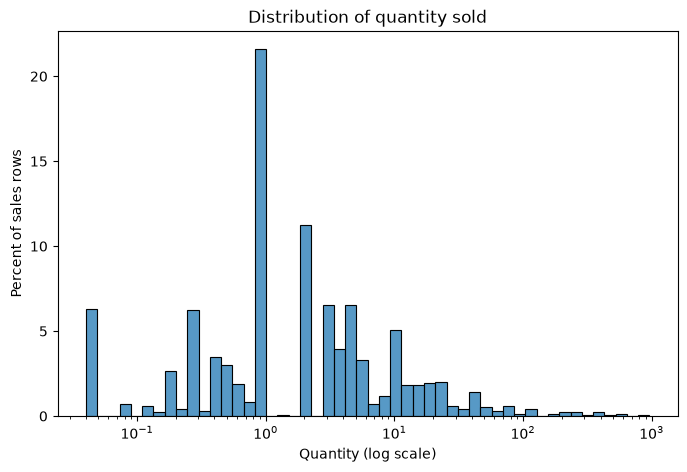

In [77]:
plt.figure(figsize=(8, 5))
sns.histplot(
    sales_positive2.loc[sales_positive2["quantity"] > 0, "quantity"],
    bins=50, log_scale=True, stat="percent"
)
plt.ylabel("Percent of sales rows")
plt.xlabel("Quantity (log scale)")
plt.title("Distribution of quantity sold")
plt.show()

<Axes: xlabel='quantity', ylabel='Density'>

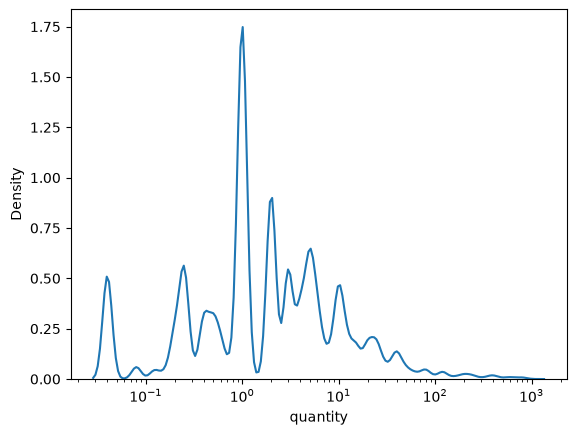

In [78]:
sns.kdeplot(sales_positive2.loc[sales_positive2["quantity"] > 0, "quantity"], log_scale=True)


In [79]:
sales_positive2[["quantity"]].describe()

,quantity
count,992692.000000
mean,9.753139
std,43.566725
min,0.000000
25%,0.600000
50%,2.000000
75%,5.000000
max,960.000000


# a)Checking the quartile to see any values above or below the Interquartile range they are considered as outliers.
## By doing this we found:
### i) 13.08% OF THE VALUES IN THE QUANTITY COLUMN SHOW LACK OF NORMAL DISTRIBUTION
### ii)129851 of the values will be called outliers

In [80]:
col = sales_positive2["quantity"]

# ---------- 1. IQR rule ----------
Q1, Q3 = col.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower Bound {lower_bound}")
print(f"Upper Bound {upper_bound}")

iqr_outliers = sales_positive2[(col < lower_bound) | (col > upper_bound)]
print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"IQR outliers: {len(iqr_outliers)} rows ({len(iqr_outliers)/len(sales_positive2):.2%})\n")



Lower Bound -6.000000000000001
Upper Bound 11.600000000000001
IQR bounds: [-6.00, 11.60]
IQR outliers: 129851 rows (13.08%)



## b)Checking the Z-score which shows the number of steps from average a values is at.One assigns a z-value to determine if "anything more than X(in which x represents z-value number) steps away is unusual"

In [81]:
# ---------- 2. Z-score ----------
z_scores = stats.zscore(col.dropna())
print(z_scores)
z_outliers = sales_positive2.loc[col.dropna().index[abs(z_scores) > 3]]
print(f"Z-score outliers (|z| > 3): {len(z_outliers)} rows ({len(z_outliers)/len(sales_positive2):.2%})\n")

[-0.06319364 -0.21743988 -0.2009135  ... -0.17796019 -0.15500688
 -0.21239015]
Z-score outliers (|z| > 3): 11186 rows (1.13%)



In [82]:
# ---------- 3. Percentiles ----------
p01, p99 = col.quantile([0.01, 0.99])
p001, p999 = col.quantile([0.001, 0.999])
print(f"1st/99th percentile bounds:   [{p01:.2f}, {p99:.2f}]")
print(f"0.1st/99.9th percentile bounds: [{p001:.2f}, {p999:.2f}]")

percentile_outliers = sales_positive2[(col < p01) | (col > p99)]
print(f"Percentile outliers (outside 1st/99th): {len(percentile_outliers)} rows ({len(percentile_outliers)/len(sales_positive2):.2%})\n")



1st/99th percentile bounds:   [0.04, 180.00]
0.1st/99.9th percentile bounds: [0.04, 720.00]
Percentile outliers (outside 1st/99th): 9715 rows (0.98%)



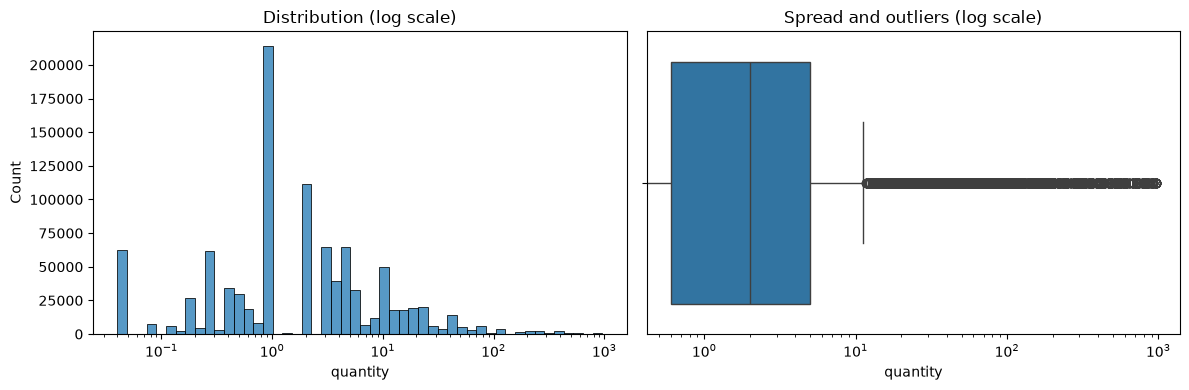

In [83]:
# ---------- 4. Visual: histogram + boxplot, log-scale ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(col[col > 0], bins=50, log_scale=True, ax=axes[0])
axes[0].set_title("Distribution (log scale)")
axes[0].set_xlabel("quantity")

sns.boxplot(x=col, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Spread and outliers (log scale)")

plt.tight_layout()
plt.show()


In [84]:
# ---------- compare how many rows each method flags ----------
print("Summary:")
print(f"  IQR:        {len(iqr_outliers)}")
print(f"  Z-score:    {len(z_outliers)}")
print(f"  Percentile: {len(percentile_outliers)}")


Summary:
  IQR:        129851
  Z-score:    11186
  Percentile: 9715


In [85]:
sales_positive2

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0


In [86]:
sales_positive2.dtypes

source_file                   str
salesperson                   str
customer_code                 str
cust_type                     str
segment                       str
visit_date         datetime64[us]
product                       str
quantity                  float64
return_quantity             int64
dtype: object

In [87]:
sales_positive2.isna().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            0
visit_date         0
product            0
quantity           0
return_quantity    0
dtype: int64

In [88]:
# 1. identify exact duplicates — every column identical, not just the key fields
exact_dupes = sales_positive2.duplicated(keep=False)
print(f"{exact_dupes.sum()} fully identical rows ({exact_dupes.mean():.2%})")




15514 fully identical rows (1.56%)


In [89]:
# 2. identify rows that share customer/date/product/quantity but differ elsewhere
key_dupes = sales_positive2.duplicated(subset=["customer_code", "visit_date", "product", "quantity"], keep=False)
ambiguous = key_dupes & ~exact_dupes
print(f"{ambiguous.sum()} rows match key fields but disagree elsewhere")



3676 rows match key fields but disagree elsewhere


In [90]:
# 3. drop the true clones — safe, no information lost
sales_positive2 = sales_positive2.drop_duplicates(keep="first")

sales_positive2

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0


In [91]:
# 4. inspect the ambiguous group separately before touching it
sales_positive2[ambiguous].sort_values(["customer_code", "visit_date", "product"])

/var/folders/tf/4wkr_3ls3jb9f452xff6b1880000gn/T/ipykernel_42694/1547830431.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sales_positive2[ambiguous].sort_values(["customer_code", "visit_date", "product"])


,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
152047,DailySalesReportNew_0104202515042025.xlsx,SEBASTIAN MUKHANZI-GILGIL,KE0026259,Cash,Bar,2025-04-05,Complete - Guiness Genius,1.0,1
152060,DailySalesReportNew_0104202515042025.xlsx,SEBASTIAN MUKHANZI-GILGIL,KE0026259,Cash,Bar,2025-04-05,Complete - Guiness Genius,1.0,0
488230,DailySalesReportNew_0111202515112025.xlsx,Clare Wanyaga,KE0026259,Cash,Bar,2025-11-14,Kenya Cane Pneap 25cl 40X01,1.0,0
514246,DailySalesReportNew_0111202515112025.xlsx,SEBASTIAN MUKHANZI-GILGIL,KE0026259,Cash,Bar,2025-11-14,Kenya Cane Pneap 25cl 40X01,1.0,0
400518,DailySalesReportNew_0108202515082025.xlsx,SEBASTIAN MUKHANZI-GILGIL,KE0026299,Credit,Specialist Store,2025-08-01,Euroform Amber Local 500ml,10.0,0
...,...,...,...,...,...,...,...,...,...
793934,DailySalesReportNew_1605202631052026.xlsx,JOEL MAINA MWAURA-UDV VAN,KE0187043,Cash,Bar,2026-05-27,Euroform Amber Local 500ml,25.0,0
794062,DailySalesReportNew_1605202631052026.xlsx,JOEL MAINA MWAURA-UDV VAN,KE0187044,Cash,Bar,2026-05-29,Kenya Cane Pneap 75cl 12X01,12.0,0
797213,DailySalesReportNew_1605202631052026.xlsx,JOSEPH MWANIKI-KANU,KE0187044,Cash,Bar,2026-05-29,Kenya Cane Pneap 75cl 12X01,12.0,0
671738,DailySalesReportNew_1603202631032026.xlsx,ERASTUS LIMO-BAHATIHESHIMA,KE0187045,Cash,Bar,2026-03-25,Manyatta C Pineapple & Mint Can 330ml 24X01,0.5,0


# Types of Analysis 
## i)Univariate Analysis
## ii)Bivariate Analysis — Target Relationship
## iii)Correlation Matrix — Multicollinearity
## iv) Multivariate Analysis — Feature Engineering


## i)Univariate Analysis
### Univariate analysis looks at one column at a time. Zero-variance analysis specifically checks whether a column ever changes value at all. If a column holds the exact same value in every row, it carries zero information — it can never help a model distinguish a churned customer from a retained one, since it looks identical no matter what the outcome is.

### Categorical column => cust_type 

In [92]:
sales_positive2

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0
...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0


In [93]:
sales_positive2["cust_type"].unique()

<ArrowStringArray>
['Cash', 'Credit']
Length: 2, dtype: str

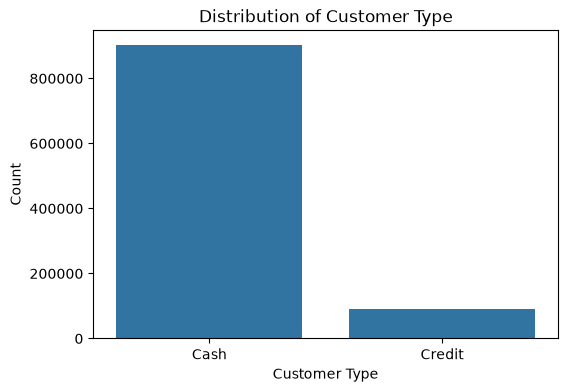

In [94]:
plt.figure(figsize=(6, 4))
sns.countplot(data=sales, x='cust_type', order=sales_positive2['cust_type'].value_counts().index)
plt.title('Distribution of Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.show()


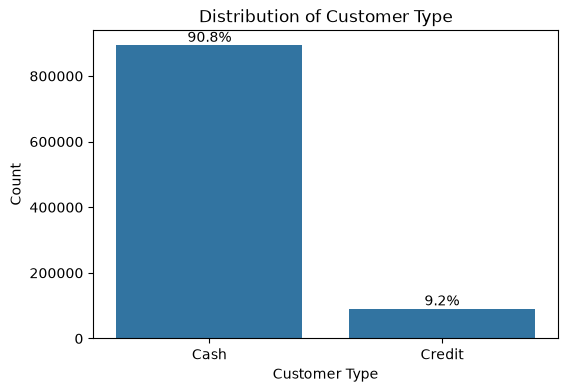

In [95]:
counts = sales_positive2['cust_type'].value_counts()
percentages = sales_positive2['cust_type'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=sales_positive2, x='cust_type', order=counts.index)
for i, (count, pct) in enumerate(zip(counts, percentages)):
    ax.text(i, count, f'{pct:.1f}%', ha='center', va='bottom')
plt.title('Distribution of Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.show()


In [96]:
# Encode Cash/Credit as 0/1 so variance can be computed
cust_type_encoded = sales_positive2['cust_type'].map({'Cash': 0, 'Credit': 1})

variance = cust_type_encoded.var()
print(f"Variance of cust_type: {variance:.4f}")


Variance of cust_type: 0.0837


In [97]:
counts = sales_positive2['cust_type'].value_counts()

# 1. Frequency ratio — most common divided by second most common
freq_ratio = counts.iloc[0] / counts.iloc[1]
print(f"Frequency ratio: {freq_ratio:.2f}")   # common rule of thumb: flag if > ~19-20

# 2. Raw unique values — catch hidden duplicates like 'Cash' vs 'cash ' vs 'CASH'
print(sales_positive2['cust_type'].unique())

# 3. Missing values — is this column even fully populated?
print(sales_positive2['cust_type'].isna().sum(), "missing out of", len(sales))


Frequency ratio: 9.84
<ArrowStringArray>
['Cash', 'Credit']
Length: 2, dtype: str
0 missing out of 993617


In [98]:
freq_table = sales_positive2['cust_type'].value_counts().to_frame('count')
freq_table['percentage'] = sales_positive2['cust_type'].value_counts(normalize=True) * 100
print(freq_table)


            count  percentage
cust_type                    
Cash       893957    90.77687
Credit      90828     9.22313


In [99]:
print(sales_positive2['cust_type'].mode()[0])


Cash


In [100]:
print(sales_positive2['cust_type'].nunique())
print(sales_positive2['cust_type'].unique())


2
<ArrowStringArray>
['Cash', 'Credit']
Length: 2, dtype: str


In [101]:
print(sales_positive2['cust_type'].isna().sum(), "missing out of", len(sales))

0 missing out of 993617


### Stability over time (does the Cash/Credit mix drift across your data window?)

#### What this means for your churn model:

#### Don't drop the column — it's still informative, this doesn't change that conclusion.
#### Be careful with train/test splitting. If you split your data randomly (not by time), you'll shuffle together transactions from the "high Credit" era (mid-2025) and the "low Credit" era (early 2026) into both train and test sets, which can hide this drift and make your model look more stable than it'll actually be in production. A time-based split (train on earlier months, test on later ones) is generally the right approach for churn anyway, but this result is a concrete reason why — it directly surfaces distribution shift you'd otherwise miss.
#### This is worth flagging as a business finding, not just a data-cleaning note — a sustained ~7-month decline in credit-based purchases (with a partial rebound) is the kind of pattern someone on the business side may already have context for (e.g. a credit policy tightening), and it could itself be related to churn (customers losing credit terms might be more likely to reduce purchasing or leave).
#### If you later check whether cust_type predicts churn, keep in mind its baseline rate itself moved over time — so any relationship you find between cust_type and churn should ideally be checked within time periods, not just pooled across the whole 15 months, to make sure it's not being confounded by this drift.


In [102]:
sales_positive2['visit_date'] = pandas.to_datetime(sales_positive2['visit_date'])
monthly_mix = sales_positive2.groupby(sales_positive2['visit_date'].dt.to_period('M'))['cust_type'].value_counts(normalize=True).unstack() * 100
print(monthly_mix)


cust_type        Cash     Credit
visit_date                      
2025-03     89.336771  10.663229
2025-04     88.940084  11.059916
2025-05     89.127372  10.872628
2025-06     88.959811  11.040189
2025-07     89.084607  10.915393
2025-08     88.854032  11.145968
2025-09     90.966062   9.033938
2025-10     90.365730   9.634270
2025-11     91.171843   8.828157
2025-12     91.557645   8.442355
2026-01     92.083635   7.916365
2026-02     92.261809   7.738191
2026-03     92.475084   7.524916
2026-04     91.568726   8.431274
2026-05     91.781419   8.218581
2026-06     91.656781   8.343219


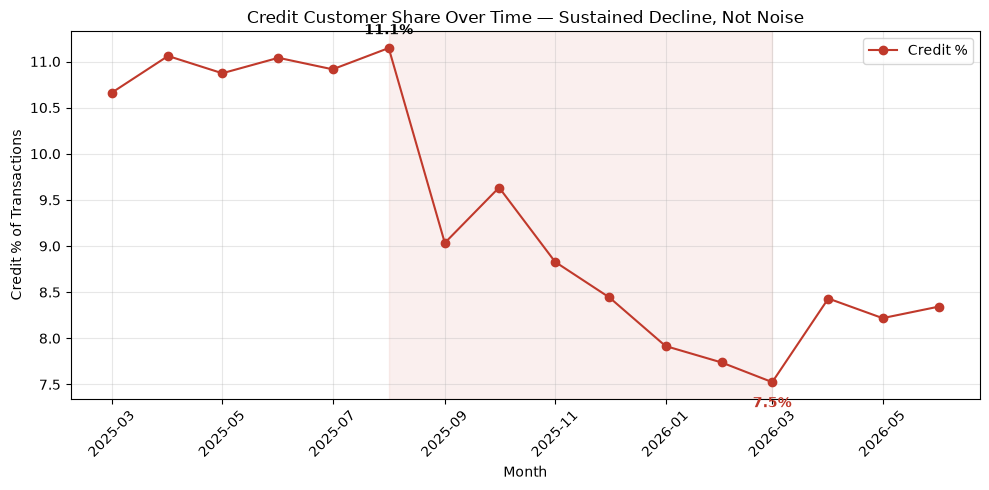

In [103]:
sales_positive2['visit_date'] = pandas.to_datetime(sales_positive2['visit_date'])
monthly_mix = (
    sales_positive2.groupby(sales_positive2['visit_date'].dt.to_period('M'))['cust_type']
    .value_counts(normalize=True)
    .unstack() * 100
)
monthly_mix.index = monthly_mix.index.to_timestamp()

plt.figure(figsize=(10, 5))
plt.plot(monthly_mix.index, monthly_mix['Credit'], marker='o', color='#c0392b', label='Credit %')

# Highlight the declining stretch (Aug 2025 - Mar 2026) to show it's a sustained trend, not noise
plt.axvspan(pandas.Timestamp('2025-08-01'), pandas.Timestamp('2026-03-01'), color='#c0392b', alpha=0.08)

plt.title('Credit Customer Share Over Time — Sustained Decline, Not Noise')
plt.xlabel('Month')
plt.ylabel('Credit % of Transactions')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

# Annotate the peak and trough to show the magnitude of the move
peak_month = monthly_mix['Credit'].idxmax()
trough_month = monthly_mix.loc['2025-08-01':'2026-03-01', 'Credit'].idxmin()
plt.annotate(f"{monthly_mix['Credit'].max():.1f}%", xy=(peak_month, monthly_mix['Credit'].max()),
             xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')
plt.annotate(f"{monthly_mix.loc[trough_month, 'Credit']:.1f}%", xy=(trough_month, monthly_mix.loc[trough_month, 'Credit']),
             xytext=(0, -18), textcoords='offset points', ha='center', fontweight='bold', color='#c0392b')

plt.legend()
plt.tight_layout()
plt.show()


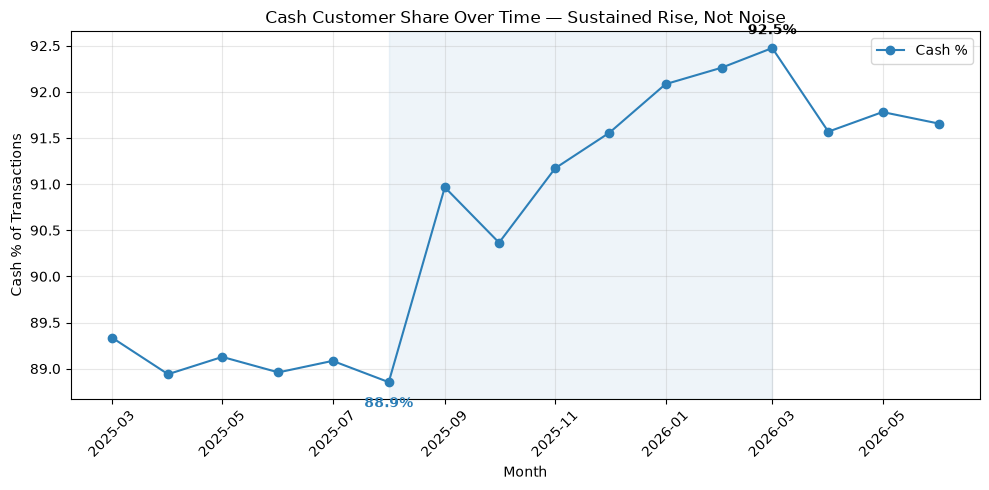

In [104]:
sales_positive2['visit_date'] = pandas.to_datetime(sales_positive2['visit_date'])
monthly_mix = (
    sales_positive2.groupby(sales['visit_date'].dt.to_period('M'))['cust_type']
    .value_counts(normalize=True)
    .unstack() * 100
)
monthly_mix.index = monthly_mix.index.to_timestamp()

plt.figure(figsize=(10, 5))
plt.plot(monthly_mix.index, monthly_mix['Cash'], marker='o', color='#2c7fb8', label='Cash %')

# Highlight the rising stretch (Aug 2025 - Mar 2026) — mirror image of Credit's decline
plt.axvspan(pandas.Timestamp('2025-08-01'), pandas.Timestamp('2026-03-01'), color='#2c7fb8', alpha=0.08)

plt.title('Cash Customer Share Over Time — Sustained Rise, Not Noise')
plt.xlabel('Month')
plt.ylabel('Cash % of Transactions')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

# Annotate the trough and peak to show the magnitude of the move
trough_month = monthly_mix['Cash'].idxmin()
peak_month = monthly_mix.loc['2025-08-01':'2026-03-01', 'Cash'].idxmax()
plt.annotate(f"{monthly_mix['Cash'].min():.1f}%", xy=(trough_month, monthly_mix['Cash'].min()),
             xytext=(0, -18), textcoords='offset points', ha='center', fontweight='bold', color='#2c7fb8')
plt.annotate(f"{monthly_mix.loc[peak_month, 'Cash']:.1f}%", xy=(peak_month, monthly_mix.loc[peak_month, 'Cash']),
             xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()


In [105]:
per_customer_variety = sales_positive2.groupby('customer_code')['cust_type'].nunique()
print((per_customer_variety > 1).sum(), "customers use both Cash and Credit")
print((per_customer_variety > 1).mean() * 100, "% of customers")


0 customers use both Cash and Credit
0.0 % of customers


### Categorical column => Segment 

## Univariate Analysis — `segment` Column

### Objective
Before using `segment` as a feature in the churn model, it needs to pass the same screening every raw column gets: is it informative enough to keep, is it clean, is it stable, and does it need any reshaping before encoding? Each check below was chosen to answer one specific part of that question.

---

### 1. Frequency Distribution (`value_counts`)
**Why:** the baseline — every other metric below is derived from this raw distribution, so it comes first.

| Segment | Count | % |
|---|---|---|
| Bar | 480,363 | 48.78% |
| Specialist Store | 397,556 | 40.37% |
| Wholesaler | 34,688 | 3.52% |
| Event | 19,558 | 1.99% |
| Lodging | 14,586 | 1.48% |
| Nightclub | 13,435 | 1.36% |
| Restaurant | 7,222 | 0.73% |
| Marketplace | 6,261 | 0.64% |
| Supermarket | 5,335 | 0.54% |
| Recreation | 3,620 | 0.37% |
| Convenience | 2,125 | 0.22% |
| Not Applicable | 36 | 0.004% |

---

### 2. Entropy — Zero-Variance Screening
**Why:** the primary test for whether a categorical column carries real information or is functionally constant. Entropy measures unpredictability, ranging from 0 (one category always occurs) to `log2(k)` (all categories equally likely).

- **Result:** 1.679 bits, vs. a theoretical max of `log2(12) = 3.585` bits (≈47% of max)
- **Verdict:** not near 0 → the column has genuine variability, **fails to qualify as zero-variance**, so it is not a drop candidate.

### 3. Gini-Simpson Index — Second Opinion on Diversity
**Why:** entropy is abstract ("bits"); Gini-Simpson gives the same underlying answer in a directly interpretable probability, useful for confirming the entropy result and for communicating it to non-technical stakeholders.

- **Result:** 0.597 (probability two random transactions fall in different segments), vs. a theoretical max of 0.917 for 12 even categories
- **Verdict:** confirms entropy's conclusion — meaningful diversity exists, well above the "near-constant" danger zone.

---

### 4. Cumulative % / Pareto View
**Why:** entropy and Gini-Simpson confirm the column overall isn't constant, but neither shows *where* the concentration sits. This identifies which categories actually carry the signal.

- **Result:** `Bar` + `Specialist Store` = 89.15% of all rows; by the 6th category (`Nightclub`), cumulative % passes 97.5%.
- **Action implied:** categories below ~1% (`Restaurant` through `Not Applicable`) should be grouped into `"Other"` before one-hot encoding, to avoid creating several near-empty dummy columns.

### 5. Frequency Ratio (Top vs. 2nd)
**Why:** a quick, standard near-zero-variance heuristic — useful on its own for 2-category columns, but included here to demonstrate its limitation on higher-cardinality columns.

- **Result:** 1.21 (`Bar` vs. `Specialist Store`)
- **Verdict:** confirms the top two categories aren't wildly imbalanced relative to each other, but says nothing about the long tail — hence the need for the cumulative-% check above.

---

### 6. Data Quality — Raw Uniques & Missing Values
**Why:** before trusting any of the statistics above, confirm they aren't distorted by dirty data (typos, case mismatches, missing values).

- **Result:** exactly 12 cleanly-spelled categories, 0 missing values out of 993,617 rows.
- **Verdict:** clean — no remediation needed before using this column.

### 7. Stability Over Time (Monthly Mix)
**Why:** a column can be informative overall while still drifting across the observation window — which matters for how train/test data should be split for a churn model that will run on future data.

- **Findings:**
  - `Specialist Store` rose steadily from 36.4% (Mar 2025) to ~41–42% (late 2025 onward), then plateaued — a real structural shift.
  - `Event` spiked sharply in March 2025 (6.54% vs. 1–3% every other month) — likely a seasonal effect or a first-month data artifact.
  - `Bar` stayed roughly flat (47.7%–51.2%) — genuine noise, no directional trend.
- **Action implied:** use a time-aware train/test split, and consider flagging or investigating the March 2025 `Event` spike separately.

### 8. `Not Applicable` Investigation
**Why:** a suspiciously-named category (0.004% of rows) warranted checking whether it's a real segment or a data artifact.

- **Result:** 36 rows total, almost entirely concentrated in a single month (June 2025).
- **Verdict:** negligible and likely a data-entry artifact — safe to fold into `"Other"` or drop the 36 rows with no meaningful information loss.

### 9. Per-Customer Consistency
**Why:** determines whether `segment` should be treated as a fixed customer-level attribute or requires aggregation (like a `%`-based feature), the same question asked of `cust_type`.

- **Result:** only 25 customers ever appear under more than one segment across all their visits.
- **Verdict:** `segment` is overwhelmingly a stable, static customer attribute — it can be used directly as a per-customer feature with no aggregation logic required.

### 10. Pareto Chart
**Why:** a single visual that ties every finding above together — the two dominant bars and the cumulative line crossing 80% almost immediately give an intuitive, at-a-glance confirmation of the long-tail structure identified numerically above.

---

### Conclusion

`segment` **passes univariate screening and should be retained** as a churn model feature:

- ✅ Not zero/near-zero-variance (entropy ≈ 47% of max, Gini-Simpson ≈ 60%)
- ✅ Clean — no missing values or data-quality issues
- ✅ Stable per customer — usable as a static feature with no aggregation needed
- ⚠️ Has a long tail — group categories below ~1% into `"Other"` before encoding
- ⚠️ Drifts modestly over time — use a time-aware train/test split and review the March 2025 `Event` spike


In [106]:
sales_positive2["segment"].unique()

<ArrowStringArray>
[             'Bar', 'Specialist Store',       'Wholesaler',
       'Restaurant',          'Lodging',            'Event',
        'Nightclub',      'Supermarket',       'Recreation',
      'Marketplace',      'Convenience',   'Not Applicable']
Length: 12, dtype: str

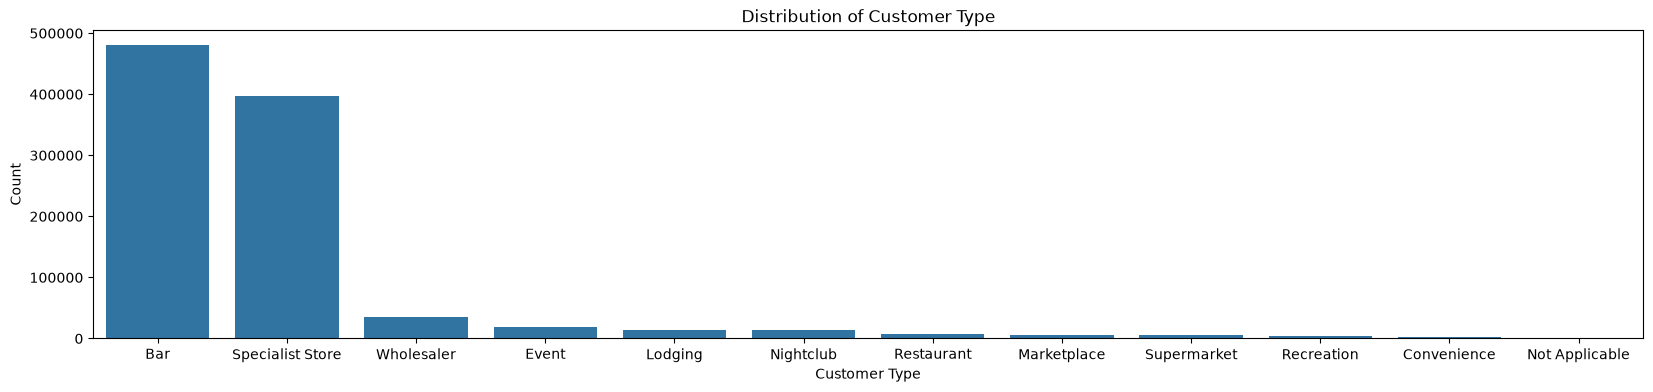

In [107]:
plt.figure(figsize=(20, 4))
sns.countplot(data=sales_positive2, x='segment', order=sales_positive2['segment'].value_counts().index)
plt.title('Distribution of Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.show()

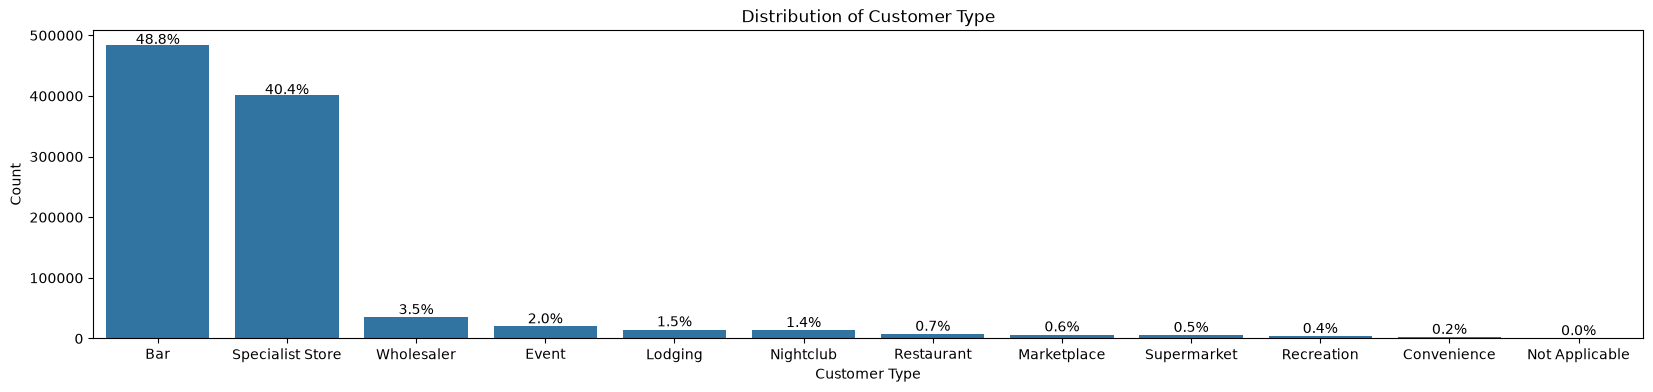

In [108]:
counts = sales_positive2['segment'].value_counts()
percentages = sales_positive2['segment'].value_counts(normalize=True) * 100

plt.figure(figsize=(20, 4))
ax = sns.countplot(data=sales, x='segment', order=counts.index)
for i, (count, pct) in enumerate(zip(counts, percentages)):
    ax.text(i, count, f'{pct:.1f}%', ha='center', va='bottom')
plt.title('Distribution of Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.show()


In [109]:
sales_positive2["segment"].value_counts()
sales_positive2["segment"].value_counts(normalize=True)   # as proportions instead of raw counts


segment
Bar                 0.487785
Specialist Store    0.403698
Wholesaler          0.035224
Event               0.019860
Lodging             0.014811
Nightclub           0.013643
Restaurant          0.007334
Marketplace         0.006358
Supermarket         0.005417
Recreation          0.003676
Convenience         0.002158
Not Applicable      0.000037
Name: proportion, dtype: float64

## Entropy here isn't a "score" where higher or lower is inherently better — it's a diagnostic for one specific question: does this column vary enough to be worth keeping? The two danger zones would be:

### Entropy near 0 (bad) — one category dominates almost completely, the column is basically constant, no predictive value, drop it.
### Entropy at the maximum, 3.585 (also not ideal, in a different way) — all 12 categories perfectly equal, which for real-world business data is actually unusual and can signal either an artificial/synthetic pattern or categories so fragmented that each one has too little data to learn from reliably.
### H = -Σ p_i × log2(p_i)

### In words: for every category, take its proportion (p_i), multiply it by log2 of itself, then sum all those up and flip the sign. That's it. The tricky part isn't the arithmetic — it's understanding why this particular formula, which the guessing-game intuition below explains.


In [110]:
proportions = sales_positive2["segment"].value_counts(normalize=True)
entropy(proportions, base=2)


np.float64(1.6789133784424208)

In [111]:
proportions = sales_positive2["segment"].value_counts(normalize=True)
gini_simpson = 1 - (proportions ** 2).sum()
print(gini_simpson)   # closer to 1 = more evenly spread across categories, closer to 0 = one category dominates


0.596911480641493


In [112]:
print(sales_positive2['segment'].mode()[0])

Bar


In [113]:
freq_table = sales_positive2['segment'].value_counts().to_frame('count')
freq_table['percentage'] = sales_positive2['segment'].value_counts(normalize=True) * 100
print(freq_table)

                   count  percentage
segment                             
Bar               480363   48.778464
Specialist Store  397556   40.369827
Wholesaler         34688    3.522393
Event              19558    1.986017
Lodging            14586    1.481135
Nightclub          13435    1.364257
Restaurant          7222    0.733358
Marketplace         6261    0.635773
Supermarket         5335    0.541743
Recreation          3620    0.367593
Convenience         2125    0.215783
Not Applicable        36    0.003656


In [114]:
counts = sales_positive2['segment'].value_counts()

# 1. Frequency ratio — most common divided by second most common
freq_ratio = counts.iloc[0] / counts.iloc[1]
print(f"Frequency ratio: {freq_ratio:.2f}")   # common rule of thumb: flag if > ~19-20

# 2. Raw unique values — catch hidden duplicates like 'Cash' vs 'cash ' vs 'CASH'
print(sales_positive2['segment'].unique())

# 3. Missing values — is this column even fully populated?
print(sales_positive2['segment'].isna().sum(), "missing out of", len(sales))

Frequency ratio: 1.21
<ArrowStringArray>
[             'Bar', 'Specialist Store',       'Wholesaler',
       'Restaurant',          'Lodging',            'Event',
        'Nightclub',      'Supermarket',       'Recreation',
      'Marketplace',      'Convenience',   'Not Applicable']
Length: 12, dtype: str
0 missing out of 993617


In [115]:
sales_positive2['visit_date'] = pandas.to_datetime(sales_positive2['visit_date'])
monthly_mix = sales_positive2.groupby(sales_positive2['visit_date'].dt.to_period('M'))['segment'].value_counts(normalize=True).unstack() * 100
print(monthly_mix)

segment           Bar  Convenience     Event   Lodging  Marketplace  \
visit_date                                                            
2025-03     48.816499     0.292946  6.538552  1.148348     0.972580   
2025-04     51.161456     0.248635  2.827138  1.608304     0.669402   
2025-05     50.121820     0.223751  2.709870  1.471783     0.885058   
2025-06     48.689574     0.201204  3.085702  1.614834     0.648709   
2025-07     47.781092     0.258303  3.367940  1.664806     0.616595   
2025-08     48.509885     0.204998  2.093460  1.677253     0.588592   
2025-09     48.400947     0.246251  2.620363  1.611681     0.587214   
2025-10     47.686287     0.293120  1.638198  1.505773     0.697834   
2025-11     48.497925     0.185793  1.742557  1.267587     0.468977   
2025-12     48.338789     0.227367  1.621332  1.655854     0.628534   
2026-01     49.707151     0.140127  1.429606  1.368202     0.665995   
2026-02     48.760410     0.228303  1.848934  1.387504     0.721888   
2026-0

In [116]:
counts = sales_positive2['segment'].value_counts()
percentages = sales_positive2['segment'].value_counts(normalize=True) * 100

# 1. Full frequency table with cumulative %
freq_table = pandas.DataFrame({'count': counts, 'pct': percentages})
freq_table['cumulative_pct'] = freq_table['pct'].cumsum()
print(freq_table)

# 2. Frequency ratio (top vs 2nd most common)
freq_ratio = counts.iloc[0] / counts.iloc[1]
print(f"Frequency ratio (Bar vs Specialist Store): {freq_ratio:.2f}")

# 3. Entropy — the correct generalized "variance" metric for >2 categories
import numpy as np
p = counts / counts.sum()
entropy = -(p * np.log2(p)).sum()
max_entropy = np.log2(len(p))
print(f"Entropy: {entropy:.3f} bits (max possible with {len(p)} categories = {max_entropy:.3f} bits)")

# 4. Raw unique values — catch typos/case issues
print(sales_positive2['segment'].unique())

# 5. Missing values
print(sales_positive2['segment'].isna().sum())


                   count        pct  cumulative_pct
segment                                            
Bar               480363  48.778464       48.778464
Specialist Store  397556  40.369827       89.148291
Wholesaler         34688   3.522393       92.670684
Event              19558   1.986017       94.656702
Lodging            14586   1.481135       96.137837
Nightclub          13435   1.364257       97.502094
Restaurant          7222   0.733358       98.235452
Marketplace         6261   0.635773       98.871226
Supermarket         5335   0.541743       99.412968
Recreation          3620   0.367593       99.780561
Convenience         2125   0.215783       99.996344
Not Applicable        36   0.003656      100.000000
Frequency ratio (Bar vs Specialist Store): 1.21
Entropy: 1.679 bits (max possible with 12 categories = 3.585 bits)
<ArrowStringArray>
[             'Bar', 'Specialist Store',       'Wholesaler',
       'Restaurant',          'Lodging',            'Event',
        'Nightcl

In [117]:
rare_segments = freq_table[freq_table['pct'] < 1.0].index
sales_positive2['segment_grouped'] = sales_positive2['segment'].where(~sales_positive2['segment'].isin(rare_segments), 'Other')


In [118]:
print(sales_positive2[sales_positive2['segment'] == 'Not Applicable'].shape[0], "rows")


36 rows


In [119]:
monthly_segment = sales_positive2.groupby(sales_positive2['visit_date'].dt.to_period('M'))['segment'].value_counts(normalize=True).unstack() * 100
monthly_segment

segment,Bar,Convenience,Event,Lodging,Marketplace,Nightclub,Not Applicable,Recreation,Restaurant,Specialist Store,Supermarket,Wholesaler
visit_date,,,,,,,,,,,,
2025-03,48.816499,0.292946,6.538552,1.148348,0.972580,1.394422,NaN,0.222639,1.394422,36.372158,0.597610,2.249824
2025-04,51.161456,0.248635,2.827138,1.608304,0.669402,1.776959,NaN,0.448586,0.768509,36.672810,0.911083,2.907118
2025-05,50.121820,0.223751,2.709870,1.471783,0.885058,1.398856,NaN,0.599983,0.870142,37.800613,0.785614,3.132510
2025-06,48.689574,0.201204,3.085702,1.614834,0.648709,1.404957,0.062443,0.300071,0.757983,39.479299,0.287930,3.467296
2025-07,47.781092,0.258303,3.367940,1.664806,0.616595,1.641475,NaN,0.229973,0.803240,39.230423,0.886563,3.519589
2025-08,48.509885,0.204998,2.093460,1.677253,0.588592,1.365098,NaN,0.616546,0.938019,39.514839,0.827755,3.663555
2025-09,48.400947,0.246251,2.620363,1.611681,0.587214,1.450671,NaN,0.230466,0.828729,39.633781,0.724546,3.665351
2025-10,47.686287,0.293120,1.638198,1.505773,0.697834,1.420962,NaN,0.276753,0.677003,41.425128,0.785621,3.593322
2025-11,48.497925,0.185793,1.742557,1.267587,0.468977,1.375466,NaN,0.331131,0.605325,41.054225,0.653272,3.817743


In [120]:
per_customer_segments = sales_positive2.groupby('customer_code')['segment'].nunique()
print((per_customer_segments > 1).sum(), "customers appear under more than one segment")


25 customers appear under more than one segment


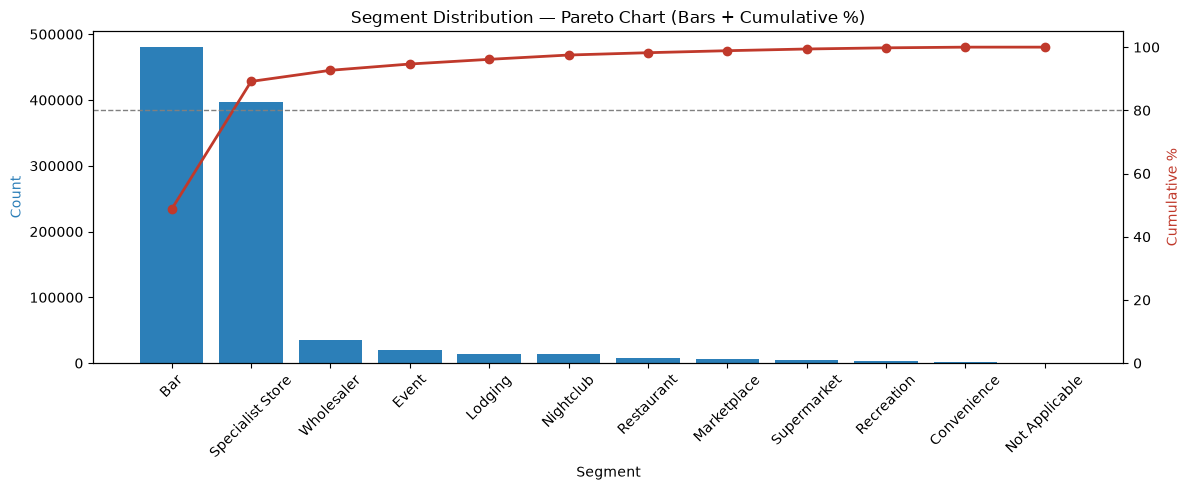

In [121]:
counts = sales_positive2['segment'].value_counts()
cumulative_pct = counts.cumsum() / counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(counts.index, counts.values, color='#2c7fb8')
ax1.set_xlabel('Segment')
ax1.set_ylabel('Count', color='#2c7fb8')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(counts.index, cumulative_pct.values, color='#c0392b', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative %', color='#c0392b')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylim(0, 105)

plt.title('Segment Distribution — Pareto Chart (Bars + Cumulative %)')
plt.tight_layout()
plt.show()


In [122]:
sales_positive2

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity,segment_grouped
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7,Bar
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0,Bar
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0,Bar
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0,Bar
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0,Bar
...,...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0,Other
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0,Other
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2,Other
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0,Other


## Categorical column => visit_date

#### The days span from 2025-03-01 to 2026-06-30 and san a total of 486 days in total

In [123]:
sales_positive2['visit_date'] = pandas.to_datetime(sales_positive2['visit_date'])
print("Min date:", sales_positive2['visit_date'].min())
print("Max date:", sales_positive2['visit_date'].max())
print("Span (days):", (sales_positive2['visit_date'].max() - sales_positive2['visit_date'].min()).days)


Min date: 2025-03-01 00:00:00
Max date: 2026-06-30 00:00:00
Span (days): 486


#### Here we are checking if there are any missing values in this column

In [124]:
print(sales_positive2['visit_date'].isna().sum(), "missing out of", len(sales_positive2))


0 missing out of 984785


visit_date
2025-03     8534
2025-04    57514
2025-05    60335
2025-06    57653
2025-07    60007
2025-08    64391
2025-09    63350
2025-10    67208
2025-11    66741
2025-12    84005
2026-01    63514
2026-02    62198
2026-03    68931
2026-04    65601
2026-05    66520
2026-06    68283
Freq: M, dtype: int64


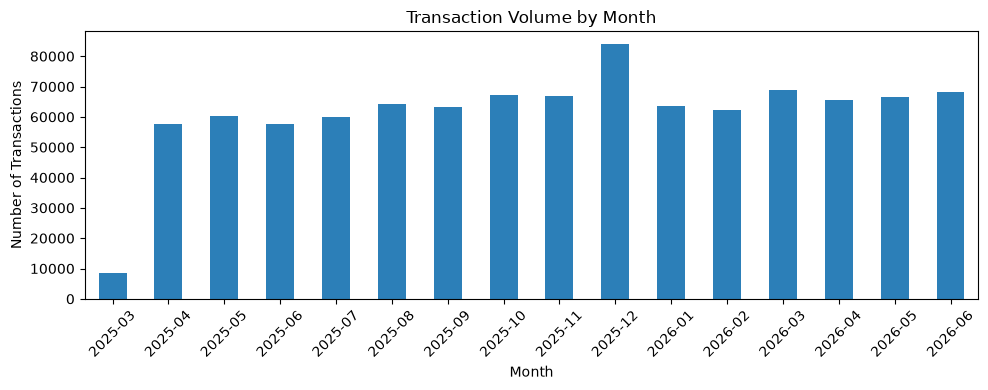

In [125]:
monthly_volume = sales_positive2.groupby(sales_positive2['visit_date'].dt.to_period('M')).size()
print(monthly_volume)

plt.figure(figsize=(10, 4))
monthly_volume.plot(kind='bar', color='#2c7fb8')
plt.title('Transaction Volume by Month')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [126]:
full_range = pandas.date_range(sales_positive2['visit_date'].min(), sales_positive2['visit_date'].max(), freq='D')
days_with_data = sales_positive2['visit_date'].dt.normalize().unique()
missing_days = full_range.difference(days_with_data)
print(len(missing_days), "days with zero recorded transactions")
print(missing_days)


88 days with zero recorded transactions
DatetimeIndex(['2025-03-02', '2025-03-06', '2025-03-07', '2025-03-08',
               '2025-03-09', '2025-03-10', '2025-03-11', '2025-03-12',
               '2025-03-13', '2025-03-14', '2025-03-15', '2025-03-16',
               '2025-03-17', '2025-03-18', '2025-03-19', '2025-03-20',
               '2025-03-21', '2025-03-22', '2025-03-23', '2025-03-24',
               '2025-03-25', '2025-03-26', '2025-03-27', '2025-03-28',
               '2025-03-29', '2025-03-30', '2025-03-31', '2025-04-06',
               '2025-04-13', '2025-04-20', '2025-04-27', '2025-05-04',
               '2025-05-11', '2025-05-18', '2025-05-25', '2025-06-01',
               '2025-06-08', '2025-06-15', '2025-06-22', '2025-06-29',
               '2025-07-06', '2025-07-13', '2025-07-20', '2025-07-27',
               '2025-08-03', '2025-08-10', '2025-08-17', '2025-08-24',
               '2025-08-31', '2025-09-07', '2025-09-14', '2025-09-21',
               '2025-09-28', '2025-10

### How `.dt.day_name()` Determines the Day of the Week

The day names aren't stored anywhere in the `visit_date` column — they're **calculated** from the date itself.

**Why this works:** every calendar date maps to exactly one day of the week. `2025-03-08` is always a Saturday, no matter what dataset it appears in, because the Gregorian calendar follows a fixed, unbroken 7-day cycle. This can be worked out with a wall calendar or a mathematical formula — pandas just performs that calculation automatically.

**What the code does:**

```python
dow_counts = sales_positive2['visit_date'].dt.day_name().value_counts()


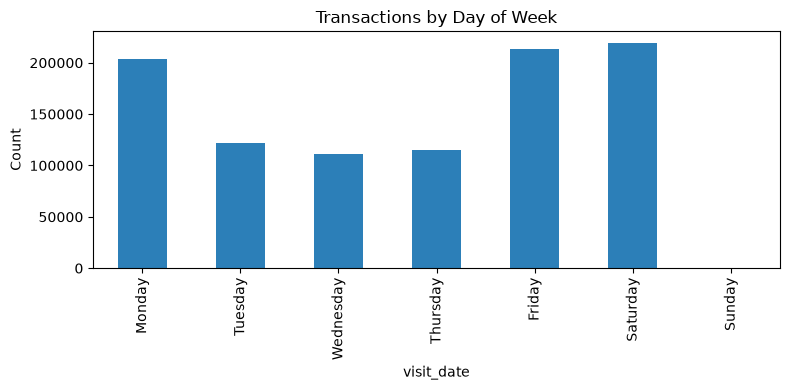

In [127]:
dow_counts = sales_positive2['visit_date'].dt.day_name().value_counts()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = dow_counts.reindex(dow_order)

plt.figure(figsize=(8, 4))
dow_counts.plot(kind='bar', color='#2c7fb8')
plt.title('Transactions by Day of Week')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


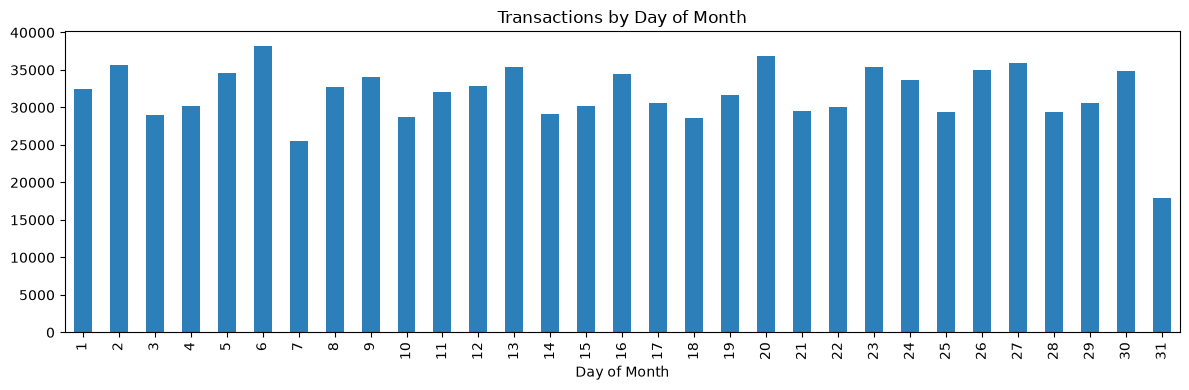

In [128]:
dom_counts = sales_positive2['visit_date'].dt.day.value_counts().sort_index()

plt.figure(figsize=(12, 4))
dom_counts.plot(kind='bar', color='#2c7fb8')
plt.title('Transactions by Day of Month')
plt.xlabel('Day of Month')
plt.tight_layout()
plt.show()


visit_date
1     32413
2     35721
3     29035
4     30154
5     34573
6     38240
7     25590
8     32681
9     34089
10    28792
11    32078
12    32922
13    35396
14    29140
15    30149
16    34476
17    30587
18    28631
19    31718
20    36829
21    29497
22    30059
23    35344
24    33624
25    29443
26    35012
27    35899
28    29403
29    30571
30    34810
31    17909
Name: count, dtype: int64


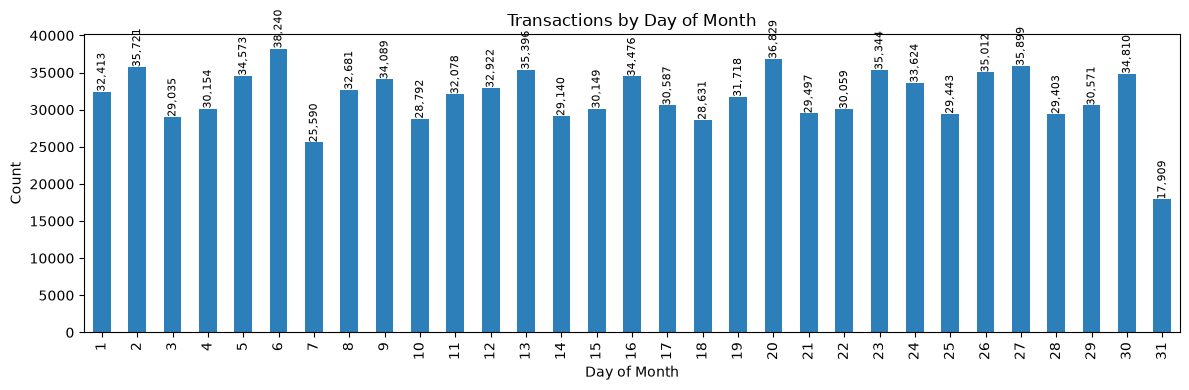

In [129]:
dom_counts = sales_positive2['visit_date'].dt.day.value_counts().sort_index()
print(dom_counts)
plt.figure(figsize=(12, 4))
ax = dom_counts.plot(kind='bar', color='#2c7fb8')

for i, count in enumerate(dom_counts):
    ax.text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=8, rotation=90)

plt.title('Transactions by Day of Month')
plt.xlabel('Day of Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Part 1 — Are there gaps in the data?**
- Counts how many distinct calendar days actually have transactions (`n_distinct`).
- Counts how many calendar days exist between the first and last date in the dataset (`span_days`).
- Compares the two: if `n_distinct` is much lower than `span_days`, it means there are stretches of days with zero recorded activity — a possible data collection gap.
- Also calculates the average number of transactions per day, as a baseline for the next check.

**Part 2 — Is any single date suspiciously overloaded?**
- Finds the 5 busiest dates in the dataset.
- Compares the busiest date's count to the average daily volume.
- A modest ratio (e.g. ~2x average) just reflects a genuinely busy real day (like a holiday).
- A very large ratio (e.g. 20x+ average) would suggest missing/unknown dates were silently filled in with one placeholder date instead of the real transaction date — a data-quality red flag.

**Why it matters:** these two checks confirm whether `visit_date` can be trusted as the foundation for recency/frequency churn features, by ruling out both missing time periods and fake/default dates.


In [130]:
# Distinct days with data vs. total calendar days in range
n_distinct = sales_positive2['visit_date'].dt.date.nunique()
(n_distinct)
span_days = (sales_positive2['visit_date'].max() - sales_positive2['visit_date'].min()).days + 1
print(span_days)
avg_per_day = len(sales_positive2) / span_days
print(avg_per_day)
print('Distinct days with data:', n_distinct, 'out of', span_days, 'calendar days in range')
print('Average rows/day:', round(avg_per_day, 1))
print()

# Check whether any single date is suspiciously overrepresented
# (a sign that missing/unknown dates were silently filled with a placeholder date)
top5 = sales_positive2['visit_date'].dt.date.value_counts().head()
print(top5)
print()
print('Max single-day count vs average:', round(top5.iloc[0] / avg_per_day, 2), 'x average')


487
2022.1457905544148
Distinct days with data: 399 out of 487 calendar days in range
Average rows/day: 2022.1

visit_date
2025-12-24    4771
2026-04-03    4310
2026-05-20    4216
2025-12-22    4086
2025-12-20    4001
Name: count, dtype: int64

Max single-day count vs average: 2.36 x average


In [131]:
sales_positive2

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity,segment_grouped
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7,Bar
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0,Bar
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0,Bar
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0,Bar
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0,Bar
...,...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0,Other
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0,Other
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2,Other
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0,Other


In [132]:
print(sales_positive2['visit_date'].dt.time.nunique())


1


## Can `visit_date` Be Trusted as a Feature?

**Yes — with one specific, precisely-identified caveat.**

### Breaking Down the 88 "Missing Days"

Investigating the gap days revealed they aren't uniform — they fall into three distinct patterns:

| Pattern | Count | What it means |
|---|---|---|
| Sundays | 66 | Not a data problem — a real, systematic weekly pattern (the business appears closed / not selling on Sundays). Expected, trustworthy behavior. |
| Scattered single days (Mon–Sat) | ~22 | A handful of one-off gaps spread across other weekdays — likely occasional holidays or minor reporting misses. Low concern given how few and non-clustered they are. |
| One 26-day consecutive block | 26 | The real finding — a solid block of missing days at the **very start** of the dataset (early-to-mid March 2025). This reflects the data collection system still ramping up, not customers going quiet — consistent with March 2025 having by far the lowest monthly transaction count (9,138 vs. 57,000–69,000 in every other month). |

### Verdict

- `visit_date` is **fundamentally trustworthy**:
  - No placeholder-date bug (the mode-date dominance check came back clean — no date is unnaturally overrepresented).
  - No missing values.
  - 66 of its 88 "gaps" turn out to be a completely normal, expected weekly closure day rather than a data-quality issue.

- **One real action item:** the first ~26 days of the dataset (early March 2025) look like an incomplete onboarding/ramp-up period, not genuine low customer activity. If recency/frequency features (or churn labels) are computed treating that stretch as normal, customers simply not yet being tracked could look artificially inactive. **Recommendation:** start the official observation window a few weeks later (roughly late March 2025 onward, once collection stabilizes), or explicitly flag/exclude the ramp-up period.

- **Clarification on "used as a feature":** the raw `visit_date` timestamp itself generally isn't fed directly into a churn model — it's the source used to *derive* features (days since last visit, purchase frequency, day-of-week/month patterns, tenure). The real question was whether this column is clean and reliable enough to build those derived features on top of — and it is, provided the March 2025 ramp-up window is handled deliberately rather than treated as uniformly reliable data.


## Categorical column => Product

### Check how many distinct products are there.

In [133]:
sales_positive2['product'].unique()

<ArrowStringArray>
[                 'Euroform Amber Local 500ml',
               'Tusker Lager 500ml Per Bottle',
        'Kenya Cane Lemon & Ginger 25cl 40X01',
                 'Smrnf Red 25Cl 40X01 Reggie',
                     'Guinness (K) Per Bottle',
             'Tusker Lite Can 500ml Can 24X01',
 'Manyatta C Pineapple & Mint Can 330ml 24X01',
                 'Smrnf Red 75Cl 12X01 Reggie',
                          'Vat 69 37.5C 04X06',
                     'Gilbeys Gin 350ml 24X01',
 ...
       'Manyatta Sweet Cider 300ml 06X04 BBIC',
             'Ciroc Red Berry 70cl      06X01',
             'Oban 12 Years SR 70cl 12Y 06X01',
        'Singleton of Dufftown 70cl 21Y 04X01',
                           'Ret 0.3300  Amber',
                  'Astral Reposado 75cl 06X01',
                                'Shot Glasses',
                                   'SIPPY CUP',
                  'Fitch & Leedes Ginger Beer',
                'JW GOT SngOfIce 1L 12X01 GOT']
Length: 258, dty

In [134]:
print(sales_positive2['product'].nunique(), "distinct product strings")


258 distinct product strings


In [135]:
print(sales_positive2['product'].isna().sum())

0


### Benefits and Importance of the Cumulative % Analysis

**1. It tells you where to spend your limited matching effort.**
You already know `product` needs to be matched against Product Master's `Product_Description`/`Handheld_Description` to bring in category, brand, and pricing info. Manually checking and fixing all 249 product names for typos/mismatches is a lot of tedious work. This analysis tells you: get the top 57 exactly right, and you've correctly handled 80% of your actual sales data. The remaining ~192 products, even if a few have messy matches, barely affect your overall data quality — because collectively they're only 20% of transactions. It turns "match everything perfectly" into "match the 57 that matter most, then don't worry as much about the rest."

**2. It prevents your feature space from exploding for almost no benefit.**
If you one-hot encode all 249 products, you get 249 new columns — but ~192 of them would be almost entirely zeros (since those products barely sold), adding size and noise to your dataset without adding real information. Knowing the 80%/95% cutoff tells you exactly how to draw the line: keep the top ~57 (or however many you choose) as their own categories, and collapse everything below that into a single `"Other"` category. You keep almost all the useful signal while cutting the column count from 249 down to something like 58.

**3. It protects your model from learning noise instead of patterns.**
A product that sold only 3 or 4 times doesn't have enough data for a model to reliably learn anything meaningful about it — any "pattern" the model finds there is more likely coincidence than a real signal (this is the classic overfitting risk with rare categories). Grouping the long tail into `"Other"` avoids feeding the model dozens of these unreliable, thin-data categories individually.

**4. It's a form of prioritization for the whole project, not just this one column.**
This is the same underlying idea as the Pareto chart you ran on `segment` — a small number of categories/products typically account for most of the real activity. Recognizing that early means you can consciously decide "I'll get the important 80-95% right, and handle the long tail cheaply/approximately," rather than spending equal effort on every single value regardless of how little it actually matters to the final result.

**5. It's an easy number to explain to non-technical people.**
"57 out of 249 products make up 80% of our sales" is a much more digestible, concrete statement than a chart or a raw table — useful if you ever need to justify a modeling decision (like grouping rare products) to someone who isn't going to read your code.


In [136]:
vc = sales_positive2['product'].value_counts()
print(vc)


product
Euroform Amber Local 500ml               57028
Smirldb&Guarana 330ml Can 24X01          42110
Kenya Cane Lemon & Ginger 25cl 40X01     35263
Smirnf Ice PP R 330ml CAN 24X01 local    33926
Kenya Cane Pneap 25cl 40X01              31861
                                         ...  
Complete - Mop up empties                    1
Manyatta Sweet Cider 300ml 06X04 BBIC        1
Ciroc Red Berry 70cl      06X01              1
Singleton of Dufftown 70cl 21Y 04X01         1
JW GOT SngOfIce 1L 12X01 GOT                 1
Name: count, Length: 258, dtype: int64


#### Individuual product Percentage share to showcase what is the percentage share of each product

In [137]:
individual_pct = vc / vc.sum() * 100
print(individual_pct)

product
Euroform Amber Local 500ml               5.790909
Smirldb&Guarana 330ml Can 24X01          4.276060
Kenya Cane Lemon & Ginger 25cl 40X01     3.580782
Smirnf Ice PP R 330ml CAN 24X01 local    3.445016
Kenya Cane Pneap 25cl 40X01              3.235325
                                           ...   
Complete - Mop up empties                0.000102
Manyatta Sweet Cider 300ml 06X04 BBIC    0.000102
Ciroc Red Berry 70cl      06X01          0.000102
Singleton of Dufftown 70cl 21Y 04X01     0.000102
JW GOT SngOfIce 1L 12X01 GOT             0.000102
Name: count, Length: 258, dtype: float64


### What This Code Does

**`cum_pct = vc.cumsum() / vc.sum() * 100`**
Builds a running total, expressed as a percentage. `vc` is already sorted from best-selling product to worst-selling product. `.cumsum()` adds up the counts one product at a time going down that list — so each value in `cum_pct` isn't "this product's own share," it's **this product's count plus every product ranked above it, combined**. Dividing by the grand total (`vc.sum()`) and multiplying by 100 converts that running sum into a percentage of all sales.

**`print(cum_pct)`**
Prints the full running-total list — starting near 5–6% (just the top product), climbing steadily, and ending at exactly 100% once every product has been added in.

**`print("Products needed for 80% of volume:", (cum_pct <= 80).sum())`**
`cum_pct <= 80` checks, for every product, whether the running total *at that point* is still under 80%. `.sum()` counts how many `True` results there are — which is exactly the number of top-selling products it takes to reach 80% of all sales.

**`print("Products needed for 95% of volume:", (cum_pct <= 95).sum())`**
Same logic, for the 95% mark instead.

### Why This Matters

This turns a long list of individual product percentages into one clear, actionable number: **exactly how many top products are responsible for the bulk of sales.** That number tells you where to focus effort (matching, cleaning, encoding) and which products can safely be grouped into an `"Other"` bucket without losing much information.


In [138]:
cum_pct = vc.cumsum() / vc.sum() * 100
print(cum_pct)
print("Products needed for 80% of volume:", (cum_pct <= 80).sum())
print("Products needed for 95% of volume:", (cum_pct <= 95).sum())


product
Euroform Amber Local 500ml                 5.790909
Smirldb&Guarana 330ml Can 24X01           10.066969
Kenya Cane Lemon & Ginger 25cl 40X01      13.647751
Smirnf Ice PP R 330ml CAN 24X01 local     17.092766
Kenya Cane Pneap 25cl 40X01               20.328092
                                            ...    
Complete - Mop up empties                 99.999594
Manyatta Sweet Cider 300ml 06X04 BBIC     99.999695
Ciroc Red Berry 70cl      06X01           99.999797
Singleton of Dufftown 70cl 21Y 04X01      99.999898
JW GOT SngOfIce 1L 12X01 GOT             100.000000
Name: count, Length: 258, dtype: float64
Products needed for 80% of volume: 47
Products needed for 95% of volume: 87


In [139]:
print((vc == 1).sum(), "products appear only once")
print((vc <= 5).sum(), "products appear 5 times or fewer")


10 products appear only once
30 products appear 5 times or fewer


### Why This Near-Duplicate Check Was Worth Running

Even though it came back with "no true duplicates," running this check was still valuable — here's why:

**1. It protects your product-level numbers from a silent, hard-to-detect error.**
If real duplicates had existed (e.g. `"Tusker Lager 500ml"` logged both as that and as `"TUSKER LAGER 500ML"`), every count, percentage, and ranking calculated earlier (the 258 distinct products, the 47/87 products needed for 80%/95% of volume, the top-10 best-sellers list) would have been wrong — a single real product's sales would look artificially split across two "different" entries, understating how important it actually is. This check is what lets you trust those earlier numbers rather than just assume they're correct.

**2. It stops you from making the opposite mistake — merging things that shouldn't be merged.**
Without checking, a reasonable-sounding shortcut would be "these two product names are 93%+ similar, let's just treat them as the same product." This check proved that would have been a real error here — collapsing `"Tusker Lite"` into `"Tusker Malt"`, or a 250ml pack into a 750ml pack, would destroy genuine differences that matter (different price, different volume, potentially different customer preference). Verifying before acting avoided a fix that would have quietly corrupted the data in the other direction.

**3. It surfaced a real, actionable data-quality issue you weren't specifically looking for.**
The `"Expired BAILEYS"` entry wasn't the thing this check was designed to catch, but it came up anyway. That's a concrete example of why exploratory checks like this earn their keep even when the main hypothesis (duplicate spellings) turns out negative — you still walked away with a real finding (a non-sale entry contaminating your `product` field) worth acting on before it distorts churn features like "total spend" or "purchase frequency."

**4. It's directly relevant to churn modeling, not just data hygiene.**
If a customer's purchase history shows them moving from `"Captain Morgan Gold 750ml"` to `"Captain Morgan Gold 250ml"`, that's potentially a meaningful behavioral signal — smaller pack size can indicate reduced spending, an early churn indicator. Had you merged these as "duplicates," that signal would have vanished before you ever got the chance to test whether it matters.

**In short:** the value of this check wasn't really "did we find duplicates" — it was confirming your `product` column is trustworthy enough to build features on, without either fragmenting real products (undetected duplicates) or erasing real distinctions (over-aggressive merging). Both outcomes were live possibilities before you ran it; now you know neither is happening.


In [140]:
products_list = sales_positive2['product'].unique().tolist()
near_duplicates = []
for i, a in enumerate(products_list):
    for b in products_list[i+1:]:
        ratio = SequenceMatcher(None, a.lower(), b.lower()).ratio()
        if ratio > 0.85:
            near_duplicates.append((a, b, round(ratio, 3)))

near_duplicates.sort(key=lambda x: -x[2])
for a, b, r in near_duplicates[:20]:
    print(f"{r} | {a!r}  vs  {b!r}")


0.972 | 'Singleton of Dufftown 70cl 12Y 06X01'  vs  'Singleton of Dufftown 70cl 18Y 06X01'
0.972 | 'Singleton of Dufftown 70cl 12Y 06X01'  vs  'Singleton of Dufftown 70cl 15Y 06X01'
0.972 | 'Singleton of Dufftown 70cl 18Y 06X01'  vs  'Singleton of Dufftown 70cl 15Y 06X01'
0.964 | 'Expired BAILEYS [750ML X 12]'  vs  'Expired BAILEYS [375ML X 12]'
0.96 | 'Captain Morgan Gold 250ml'  vs  'Captain Morgan Gold 750ml'
0.944 | 'Singleton of Dufftown 70cl 12Y 06X01'  vs  'Singleton of Dufftown 70cl 21Y 04X01'
0.944 | 'Singleton of Dufftown 70cl 18Y 06X01'  vs  'Singleton of Dufftown 70cl 21Y 04X01'
0.944 | 'Singleton of Dufftown 70cl 15Y 06X01'  vs  'Singleton of Dufftown 70cl 21Y 04X01'
0.938 | 'Baileys Orig    75cl      12X01*'  vs  'Baileys Orig    37.5c     12X01*'
0.936 | 'Captain Morgan Muckpit Melon Splash 750ml 12x01'  vs  'Captain Morgan Muckpit Melon Splash 250ml 40x01'
0.933 | 'JW GOT SngOfFir 75cl 12X01 GOT'  vs  'JW GOT SngOfIce 75cl 12X01 GOT'
0.931 | 'Richot Brandy 25Cl 40X01 5 

product
Euroform Amber Local 500ml               57028
Smirldb&Guarana 330ml Can 24X01          42110
Kenya Cane Lemon & Ginger 25cl 40X01     35263
Smirnf Ice PP R 330ml CAN 24X01 local    33926
Kenya Cane Pneap 25cl 40X01              31861
                                         ...  
Complete - Mop up empties                    1
Manyatta Sweet Cider 300ml 06X04 BBIC        1
Ciroc Red Berry 70cl      06X01              1
Singleton of Dufftown 70cl 21Y 04X01         1
JW GOT SngOfIce 1L 12X01 GOT                 1
Name: count, Length: 258, dtype: int64


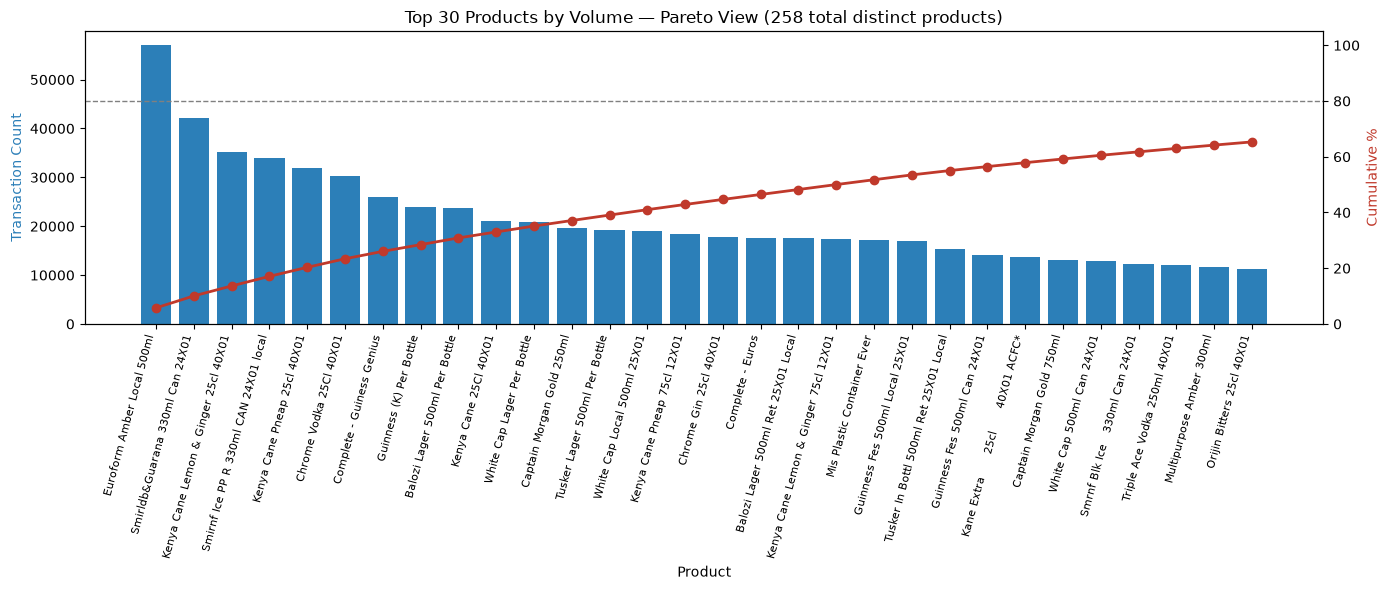

In [141]:
vc = sales_positive2['product'].value_counts()
print(vc)
cum_pct = vc.cumsum() / vc.sum() * 100

top_n = 30
top_products = vc.head(top_n)
top_cum_pct = cum_pct.head(top_n)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(range(top_n), top_products.values, color='#2c7fb8')
ax1.set_xticks(range(top_n))
ax1.set_xticklabels(top_products.index, rotation=75, ha='right', fontsize=8)
ax1.set_xlabel('Product')
ax1.set_ylabel('Transaction Count', color='#2c7fb8')

ax2 = ax1.twinx()
ax2.plot(range(top_n), top_cum_pct.values, color='#c0392b', marker='o', linewidth=2)
ax2.set_ylabel('Cumulative %', color='#c0392b')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylim(0, 105)

plt.title(f'Top {top_n} Products by Volume — Pareto View ({vc.shape[0]} total distinct products)')
plt.tight_layout()
plt.show()


### Conclusions from This Chart

**1. Product sales are meaningfully concentrated, but not extremely so.**
The top 30 products (out of 258) account for ~65% of all transactions — a real concentration, but nowhere near as extreme as `segment` (where just 2 of 12 categories covered 89%). This is a longer, more gradual tail than `segment` had.

**2. 80% coverage requires going beyond the top 30.**
Confirmed by the cumulative line not reaching the dashed threshold within this view. The earlier calculation showed it takes 47 products to get there, meaning ~211 of the 258 products together contribute only the remaining 20%. That's the practical cutoff to use for any "top-N products, rest = Other" grouping decision.

**3. The `product` column needs a cleaning pass before it can be trusted for ranking or feature engineering.**
This chart surfaced non-product entries (`"Complete - Guiness Genius"`, `"Complete - Euros"`, `"Mis Plastic Container Ever"`) sitting at meaningfully high volume — not buried in the rare tail, but inside the top 20–30 best-"sellers." If these are administrative/inventory entries rather than real purchases (consistent with the `"Expired BAILEYS"` and `"Complete - Mop up empties"` anomalies found earlier), they're currently inflating transaction counts and distorting both the ranking and the cumulative-% figures by a non-trivial amount — this needs to be resolved before the 47-products-for-80% number can be fully trusted.

**Net conclusion:** the shape of the distribution (moderate long tail) is usable for feature engineering as planned (top-N products individually, rest grouped as `"Other"`), but the exact cutoff number (47) and the top-products list itself are provisional until it's confirmed which of these high-ranking entries are real product sales versus internal/administrative log entries that don't belong in a customer-purchase analysis at all.


#### Why it matters: gives you a precise, comparable number (rather than a visual impression) confirming product isn't a zero/near-zero-variance column — and lets you directly compare its concentration level to segment's (1.679 bits / 0.597) on the same scale.

In [142]:
p = vc / vc.sum()

entropy = -(p * np.log2(p)).sum()
max_entropy = np.log2(len(p))
print(f"Entropy: {entropy:.3f} bits (max possible with {len(p)} categories = {max_entropy:.3f} bits)")

gini_simpson = 1 - (p ** 2).sum()
print(f"Gini-Simpson: {gini_simpson:.4f}")


Entropy: 6.241 bits (max possible with 258 categories = 8.011 bits)
Gini-Simpson: 0.9807


In [143]:
freq_ratio = vc.iloc[0] / vc.iloc[1]
print(f"Frequency ratio: {freq_ratio:.2f}")


Frequency ratio: 1.35


In [144]:
top10 = vc.head(10).index
monthly_top10 = (
    sales_positive2[sales_positive2['product'].isin(top10)]
    .groupby(sales_positive2['visit_date'].dt.to_period('M'))['product']
    .value_counts(normalize=True)
    .unstack() * 100
)
print(monthly_top10)


product     Balozi Lager 500ml Per Bottle  Chrome Vodka 25Cl 40X01  \
visit_date                                                           
2025-03                          8.185053                15.258007   
2025-04                          7.714825                13.224484   
2025-05                          7.255921                12.021953   
2025-06                          7.143665                11.216063   
2025-07                          7.108168                11.252759   
2025-08                          7.626405                10.776011   
2025-09                          8.239103                10.556937   
2025-10                          7.710510                 9.125815   
2025-11                          6.619762                 9.004823   
2025-12                          6.378206                 8.704461   
2026-01                          7.282631                 8.476849   
2026-02                          7.698181                 8.210195   
2026-03             

In [145]:
products_per_customer = sales_positive2.groupby('customer_code')['product'].nunique()
print(products_per_customer.describe())


count    948.000000
mean      68.977848
std       30.528615
min        1.000000
25%       50.000000
50%       70.000000
75%       90.000000
max      178.000000
Name: product, dtype: float64


In [146]:
suspect_pattern = sales_positive2['product'].str.contains(
    r'^(Complete -|Expired|Mis )', case=False, na=False, regex=True
)
print(suspect_pattern.sum(), "rows match suspected non-product patterns")
print(f"{suspect_pattern.mean():.2%} of all transactions")
print(sales_positive2.loc[suspect_pattern, 'product'].value_counts())


/var/folders/tf/4wkr_3ls3jb9f452xff6b1880000gn/T/ipykernel_42694/1852405627.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  suspect_pattern = sales_positive2['product'].str.contains(


77205 rows match suspected non-product patterns
7.84% of all transactions
product
Complete - Guiness Genius                        26032
Complete - Euros                                 17576
Mis Plastic Container Ever                       17127
Mis Standard Complete Lite                        5111
Complete - M/P Amber In Lps                       4063
Mis Plastic Container Long                        3624
Complete - M/P  Ren Flint In Lps                  3018
Complete - Gucci                                   634
Expired TUSKER NDIMU 330ML X25                       3
Expired Gordons Premix Pink & Tonic Can 330ml        2
Expired Gordons Premix Dry & Tonic 330ml             2
Expired BAILEYS [750ML X 12]                         2
Expired GUINNESS SMOOTH [300ML X 25]                 2
Expired BAILEYS STRAWBERRIES [700ML X 12]            2
Expired White Cap Crisp 330ml CAN 24X01              2
Expired GUINNESS SMOOTH CAN [330ML X 24]             2
Expired BAILEYS [375ML X 12]          

In [147]:
sales_positive2

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity,segment_grouped
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7,Bar
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0,Bar
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0,Bar
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0,Bar
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0,Bar
...,...,...,...,...,...,...,...,...,...,...
1153191,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Dbl Blck 1L 12X01,2.00,0,Other
1153192,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Smirldb&Guarana 330ml Can 24X01,1.00,0,Other
1153193,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,Complete - M/P Amber In Lps,2.00,2,Other
1153194,DailySalesReportNew_162202628022026.xlsx,Martha Mwende,KE0167997,Cash,Marketplace,2026-02-27,J Wlkr Black 75Cl 12Y 12X01,3.00,0,Other


In [148]:
sales_positive2.isna().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            0
visit_date         0
product            0
quantity           0
return_quantity    0
segment_grouped    0
dtype: int64

In [149]:
sales_positive2.to_csv("../eabl parsed csv/eabl_sales_consolidated_cleaned.csv", index=False)

In [150]:
sales_positive2.isna().sum()

source_file        0
salesperson        0
customer_code      0
cust_type          0
segment            0
visit_date         0
product            0
quantity           0
return_quantity    0
segment_grouped    0
dtype: int64

The notebook's own header promises 4 sections ("Missing Values," "Numerical Variable," "Categorical Variable," "Finding Relationships between features") — only the first three are done. Section 4 never happened.
Cell 196–198: the notebook correctly diagnoses that quantity mixes bottles/cases/pallets and starts a "Converting quantity to Bottle_Quantity" section — the header exists, the code cell is empty. This is the single blocking prerequisite for the elasticity analysis (and for #9's NSV work, and honestly for almost every quantity-based number computed earlier in that notebook).
Cell 193 only checks the match rate of product against Product Master descriptions — it never actually performs the merge and never carries Brand/Pack_Format/price columns into the sales table.
No join to Customer Master has been attempted anywhere, so the customer_code ↔ Customer Master ID key has never been validated.

### Since In this case, IQR and z-score assume one coherent cluster, but the quantity column actually contains several separate multiplicative clusters eg 1 bottle, 1 case, 1 pallet... stacked on top of each other because of the unit mixing. IQR and z-score can't "see" that structure — they just report very different numbers because they're each being fooled by it in a different way. 

## 3. Converting of the quantity to Bottle_Quantity

In [151]:
joined_sales_product = pandas.read_csv("../eabl parsed csv/sales_products_merged.csv")
joined_sales_product

,source_file,salesperson,customer_code,cust_type,segment,visit_date,product,quantity,return_quantity,segment_grouped,...,Sub_Category1,CATMAN_Category,FY25_July_NSV_Conversion_1st,FY25_November_NSV_Conversion_1st,FY25_January_NSV_Conversion_1st,FY26_October_NSV_Conversion_18th,FY25_EX_KBL_Price_Per_Case,FY26_October_NSV_Conversion_18th_Updated,FY26_June_NSV_Conversion_15th,FY26_EX_KBL_Price_Per_Case
0,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Euroform Amber Local 500ml,7.00,7,Bar,...,Bottles/Crates,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
1,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Tusker Lager 500ml Per Bottle,0.28,0,Bar,...,Lager,Lager,1687.169954,1687.169954,2286.444954,2286.444954,4045.697200,2286.444954,2286.444954,3933.747412
2,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Kenya Cane Lemon & Ginger 25cl 40X01,1.00,0,Bar,...,Rum,Cane/Bitters,1.000000,97.775000,109.860836,109.860836,9739.298206,134.860836,134.860836,9737.542792
3,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Smrnf Red 25Cl 40X01 Reggie,2.00,0,Bar,...,Vodka,Vodka,251.917884,251.917884,247.273859,247.273859,15825.727060,247.273859,247.273859,15823.507037
4,DailySalesReportNew_0101202615012026.xlsx,JOHN MWANGI-CBD,KE0062192,Cash,Bar,2026-01-08,Guinness (K) Per Bottle,0.60,0,Bar,...,Ale,Stout,2397.221778,2397.221778,2349.621778,2349.621778,4869.355200,2349.621778,2349.621778,4846.186262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
984780,DailySalesReportNew_1611202530112025.xlsx,Clare Wanyaga,KE0111447,Cash,Specialist Store,2025-11-18,Fitch & Leedes Ginger Beer,10.00,0,Specialist Store,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
984781,DailySalesReportNew_1612202531122025.xlsx,KEY ACCOUNT,KE0061633,Credit,Nightclub,2025-12-27,Fitch & Leedes Pink Tonic,12.00,0,Nightclub,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
984782,DailySalesReportNew_1612202531122025.xlsx,KEY ACCOUNT,KE0157788,Credit,Specialist Store,2025-12-20,Free Soda 330ml,120.00,0,Specialist Store,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
984783,DailySalesReportNew_1612202531122025.xlsx,JOSPHAT ONDIGO-PIPELINE,KE0061692,Credit,Specialist Store,2025-12-19,Free Soda 330ml,120.00,0,Specialist Store,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [152]:
joined_sales_product.isna().sum()

source_file                                    0
salesperson                                    0
customer_code                                  0
cust_type                                      0
segment                                        0
visit_date                                     0
product                                        0
quantity                                       0
return_quantity                                0
segment_grouped                                0
Product_Code                                1223
Product_Description                         1223
Handheld_Description                        1223
Status                                      1223
Default_UOM                                 1223
Category                                    1223
Sub_Category                                1223
New_Sub_Category2                           1223
Brand                                       1223
SKU                                         1223
Pack_Format         

In [153]:
import pandas as pd
pd.set_option('display.max_rows', None)

# 1. Isolate the unmatched rows
missing_mask = joined_sales_product['Product_Code'].isna()
missing = joined_sales_product[missing_mask]
print("Unmatched row count:", len(missing))          # should be 1223

# 2. Confirm it's the SAME 1223 rows across every product-master column
#    (not different rows coincidentally producing the same count)
pm_cols = ['Product_Code', 'Product_Description', 'Handheld_Description', 'Status',
           'Default_UOM', 'Category', 'Sub_Category', 'Brand', 'SKU']  # add the rest as needed
mask_agreement = joined_sales_product[pm_cols].isna().apply(lambda col: col.equals(missing_mask), axis=0)
print(mask_agreement)   # all True confirms one shared cause, not separate issues per column

# 3. Full (untruncated) product name breakdown — no .head(20) this time
full_counts = missing['product'].value_counts()
print(full_counts)
print("Sum:", full_counts.sum())   # should equal 1223 exactly now

# 4. Where in the data these unmatched rows occur
print("\nBy source file:")
print(missing['source_file'].value_counts())

print("\nBy customer segment:")
print(missing['segment'].value_counts())

print("\nDate range of unmatched rows:")
print(missing['visit_date'].min(), "to", missing['visit_date'].max())

print("\nHow many distinct customers affected:")
print(missing['customer_code'].nunique())

# 5. Materiality — how much quantity these unmatched rows represent
print("\nTotal quantity in unmatched rows:", missing['quantity'].sum())
print("As % of all sales quantity:", missing['quantity'].sum() / joined_sales_product['quantity'].sum())

# 6. Export for manual review / to hand to whoever maintains product master
missing.to_csv('../eabl parsed csv/unmatched_products_review.csv', index=False)


Unmatched row count: 1223
Product_Code            True
Product_Description     True
Handheld_Description    True
Status                  True
Default_UOM             True
Category                True
Sub_Category            True
Brand                   True
SKU                     True
dtype: bool
product
Smirnoff Ice Raspberry Twist 300ml in Bottle          730
Free Soda Lime 300ml                                   83
Sprite 1.25L                                           62
Ceres Apple Juice 1L                                   41
Sample Chrome Brandy 25cl 40X01                        38
Sample Smirnoff Ice Raspberry Twist 300ml in Bottl     36
Delmonte Pineapple                                     35
Fitch & Leeds                                          27
Schweppes 500ml                                        23
Sample Astral Blanco 75cl 06X01 *                      23
Fitch & Leedes Lemonade                                19
Sprite 500ml                                           

In [154]:
# Unique product names among the 1223 unmatched rows (no counts, just the list)
unique_unmatched_products = missing['product'].unique()
print("Number of distinct unmatched product names:", len(unique_unmatched_products))
for name in sorted(unique_unmatched_products):
    print(name)


Number of distinct unmatched product names: 36
Ceres Apple Juice 1L
Cocktail Shaker
Complete - Mop up empties
Dasani 1 litre
Delmonte Pineapple
Expired BAILEYS STRAWBERRIES [700ML X 12]
Expired BAILEYS [375ML X 12]
Expired BAILEYS [750ML X 12]
Expired GUINNESS SMOOTH CAN [330ML X 24]
Expired GUINNESS SMOOTH [300ML X 25]
Expired Gordons Premix Dry & Tonic 330ml
Expired Gordons Premix Pink & Tonic Can 330ml
Expired TUSKER NDIMU 330ML X25
Expired White Cap Crisp 330ml CAN 24X01
Fitch & Leedes Ginger Beer
Fitch & Leedes Lemonade
Fitch & Leedes Pink Tonic
Fitch & Leeds
Free Club Soda Lemonade  300ml
Free Soda 330ml
Free Soda Lime 300ml
Ginger Ale 330ml
Guinness Goblets
Lemonade 300ml
SIPPY CUP
Sample Astral Blanco 75cl 06X01 *
Sample Chrome Brandy 25cl 40X01
Sample Smirnoff Ice Raspberry Twist 300ml in Bottl
Schweppes 500ml
Shot Glasses
Singleton Whiskey Flask
Smirnoff Ice Raspberry Twist 300ml in Bottle
Sprite 1.25L
Sprite 1L
Sprite 500ml
Sprite 750ml


In [155]:
# Or, to see the actual rows (not just names) — every transaction that has a null product match
missing[['product', 'source_file', 'visit_date', 'customer_code', 'segment', 'quantity']]

# Or as a clean summary table: product name, how many times it occurs, and total quantity involved
summary = missing.groupby('product').agg(
    occurrences=('product', 'size'),
    total_quantity=('quantity', 'sum')
).sort_values('occurrences', ascending=False)

print(summary)


                                                    occurrences  \
product                                                           
Smirnoff Ice Raspberry Twist 300ml in Bottle                730   
Free Soda Lime 300ml                                         83   
Sprite 1.25L                                                 62   
Ceres Apple Juice 1L                                         41   
Sample Chrome Brandy 25cl 40X01                              38   
Sample Smirnoff Ice Raspberry Twist 300ml in Bottl           36   
Delmonte Pineapple                                           35   
Fitch & Leeds                                                27   
Schweppes 500ml                                              23   
Sample Astral Blanco 75cl 06X01 *                            23   
Fitch & Leedes Lemonade                                      19   
Sprite 500ml                                                 16   
Ginger Ale 330ml                                             1

In [156]:
import pandas as pd

joined_sales_product = joined_sales_product.copy()
unmatched_mask = joined_sales_product['Product_Code'].isna()

# ── 0. Fix known spelling inconsistency BEFORE grouping ──
# "Fitch & Leeds" (730-row-adjacent typo) and "Fitch & Leedes" are the same brand.
# Left unfixed, they'd show up as two separate lines on the hand-off list.
joined_sales_product.loc[joined_sales_product['product'] == 'Fitch & Leeds', 'product'] = 'Fitch & Leedes'

# ── 1. Identify the "junk" bucket — drop these regardless ──
is_expired      = joined_sales_product['product'].str.startswith('Expired', na=False)
is_admin        = joined_sales_product['product'] == 'Complete - Mop up empties'
is_sample       = joined_sales_product['product'].str.startswith('Sample', na=False)
merchandise     = ['Guinness Goblets', 'Cocktail Shaker', 'Shot Glasses',
                    'SIPPY CUP', 'Singleton Whiskey Flask']
is_merchandise  = joined_sales_product['product'].isin(merchandise)

drop_mask = unmatched_mask & (is_expired | is_admin | is_sample | is_merchandise)
print("Rows being dropped (expired/admin/sample/merchandise):", drop_mask.sum())

joined_sales_product = joined_sales_product[~drop_mask].copy()

# ── 2. Remaining unmatched rows = real products just missing from product master ──
still_unmatched = joined_sales_product['Product_Code'].isna()
print("Real unmapped product rows remaining:", still_unmatched.sum())

# Flag the descriptive/categorical columns instead of leaving them NaN
text_cols = ['Product_Description', 'Handheld_Description', 'Status', 'Default_UOM',
             'Category', 'Sub_Category', 'New_Sub_Category2', 'Brand', 'SKU',
             'Pack_Format', 'Battleground_Category', 'Sub_Category1', 'CATMAN_Category']
for col in text_cols:
    joined_sales_product.loc[still_unmatched, col] = 'Unmapped'

# Numeric NSV/price/conversion columns are left as NaN on purpose —
# so sums/averages skip them instead of treating them as 0
numeric_cols = ['Bottles_Per_Case', 'Pack_Size_mls', 'Cases_Conversion', 'EU_Conversion',
                 'FY25_July_NSV_Conversion_1st', 'FY25_November_NSV_Conversion_1st',
                 'FY25_January_NSV_Conversion_1st', 'FY26_October_NSV_Conversion_18th',
                 'FY25_EX_KBL_Price_Per_Case', 'FY26_October_NSV_Conversion_18th_Updated',
                 'FY26_June_NSV_Conversion_15th', 'FY26_EX_KBL_Price_Per_Case']
# (already NaN — no action needed, just documenting intent)

print("\nFinal row count:", len(joined_sales_product), " (started with", len(joined_sales_product), ")")
joined_sales_product.to_csv('../eabl parsed csv/sales_products_merged_cleaned.csv', index=False)

# ── 3. Hand-off file: real products missing from the master, for EABL's product team ──
handoff = (
    joined_sales_product[still_unmatched]
    .groupby('product')
    .agg(occurrences=('product', 'size'), total_quantity=('quantity', 'sum'))
    .sort_values('occurrences', ascending=False)
    .reset_index()
)
handoff.to_csv('../eabl parsed csv/products_missing_from_master_TO_ADD.csv', index=False)
print("\nHand-off list for product master team:")
print(handoff)


Rows being dropped (expired/admin/sample/merchandise): 144
Real unmapped product rows remaining: 1079

Final row count: 984641  (started with 984641 )

Hand-off list for product master team:
                                         product  occurrences  total_quantity
0   Smirnoff Ice Raspberry Twist 300ml in Bottle          730          221.88
1                           Free Soda Lime 300ml           83         1250.00
2                                   Sprite 1.25L           62          395.00
3                           Ceres Apple Juice 1L           41           92.00
4                             Delmonte Pineapple           35          128.00
5                                 Fitch & Leedes           27          140.00
6                                Schweppes 500ml           23          236.00
7                        Fitch & Leedes Lemonade           19          102.00
8                                   Sprite 500ml           16          115.00
9                            

In [157]:
joined_sales_product.isna().sum()


source_file                                    0
salesperson                                    0
customer_code                                  0
cust_type                                      0
segment                                        0
visit_date                                     0
product                                        0
quantity                                       0
return_quantity                                0
segment_grouped                                0
Product_Code                                1079
Product_Description                            0
Handheld_Description                           0
Status                                         0
Default_UOM                                    0
Category                                       0
Sub_Category                                   0
New_Sub_Category2                              0
Brand                                          0
SKU                                            0
Pack_Format         

In [158]:
import pandas as pd

product_master = pd.read_csv('../eabl parsed csv/product_master_cleaned.csv')

master_cols = ['Product_Code', 'Product_Description', 'Handheld_Description', 'Status', 'Default_UOM',
               'Category', 'Sub_Category', 'New_Sub_Category2', 'Brand', 'SKU', 'Pack_Format',
               'Bottles_Per_Case', 'Pack_Size_mls', 'Cases_Conversion', 'EU_Conversion',
               'Battleground_Category', 'Sub_Category1', 'CATMAN_Category',
               'FY25_July_NSV_Conversion_1st', 'FY25_November_NSV_Conversion_1st',
               'FY25_January_NSV_Conversion_1st', 'FY26_October_NSV_Conversion_18th',
               'FY25_EX_KBL_Price_Per_Case', 'FY26_October_NSV_Conversion_18th_Updated',
               'FY26_June_NSV_Conversion_15th', 'FY26_EX_KBL_Price_Per_Case']

# ── Known alias: sales 'product' text -> real Product_Code in the master ──
# Verified manually: "Smirnoff Ice Raspberry Twist 300ml in Bottle" (sales wording)
# is the same SKU as Product_Code 800939 in the master — it only failed the
# exact-string merge, it isn't actually missing.
product_aliases = {
    'Smirnoff Ice Raspberry Twist 300ml in Bottle': '800939',
}

df = joined_sales_product.copy()

recoverable_mask = df['Product_Code'].isna() & df['product'].isin(product_aliases)
print("Rows recovered via known alias:", recoverable_mask.sum())

for sales_name, code in product_aliases.items():
    row_mask = recoverable_mask & (df['product'] == sales_name)
    master_row = product_master.loc[product_master['Product_Code'].astype(str) == code, master_cols]
    if master_row.empty:
        print(f"WARNING: code {code} not found in master — skipping {sales_name}")
        continue
    for col in master_cols:
        df.loc[row_mask, col] = master_row.iloc[0][col]

print("Product_Code still missing after alias recovery:", df['Product_Code'].isna().sum())

# ── From here, same drop/Unmapped logic as before, now on the recovered df ──
unmatched_mask = df['Product_Code'].isna()

df.loc[df['product'] == 'Fitch & Leeds', 'product'] = 'Fitch & Leedes'

is_expired      = df['product'].str.startswith('Expired', na=False)
is_admin        = df['product'] == 'Complete - Mop up empties'
is_sample       = df['product'].str.startswith('Sample', na=False)
merchandise     = ['Guinness Goblets', 'Cocktail Shaker', 'Shot Glasses',
                    'SIPPY CUP', 'Singleton Whiskey Flask']
is_merchandise  = df['product'].isin(merchandise)

drop_mask = unmatched_mask & (is_expired | is_admin | is_sample | is_merchandise)
print("Rows being dropped (expired/admin/sample/merchandise):", drop_mask.sum())

df_cleaned = df[~drop_mask].copy()

still_unmatched = df_cleaned['Product_Code'].isna()
print("Genuinely missing-from-master rows remaining:", still_unmatched.sum())

text_cols = ['Product_Description', 'Handheld_Description', 'Status', 'Default_UOM',
             'Category', 'Sub_Category', 'New_Sub_Category2', 'Brand', 'SKU',
             'Pack_Format', 'Battleground_Category', 'Sub_Category1', 'CATMAN_Category']
for col in text_cols:
    df_cleaned.loc[still_unmatched, col] = 'Unmapped'

print("\nFinal row count:", len(df_cleaned), " (started with", len(df), ")")
df_cleaned.to_csv('../eabl parsed csv/sales_products_merged_cleaned.csv', index=False)

handoff = (
    df_cleaned[still_unmatched]
    .groupby('product')
    .agg(occurrences=('product', 'size'), total_quantity=('quantity', 'sum'))
    .sort_values('occurrences', ascending=False)
    .reset_index()
)
handoff.to_csv('../eabl parsed csv/products_missing_from_master_TO_ADD.csv', index=False)
print("\nHand-off list (genuinely absent from master):")
print(handoff)


Rows recovered via known alias: 730
Product_Code still missing after alias recovery: 349
Rows being dropped (expired/admin/sample/merchandise): 0
Genuinely missing-from-master rows remaining: 349

Final row count: 984641  (started with 984641 )

Hand-off list (genuinely absent from master):
                           product  occurrences  total_quantity
0             Free Soda Lime 300ml           83          1250.0
1                     Sprite 1.25L           62           395.0
2             Ceres Apple Juice 1L           41            92.0
3               Delmonte Pineapple           35           128.0
4                   Fitch & Leedes           27           140.0
5                  Schweppes 500ml           23           236.0
6          Fitch & Leedes Lemonade           19           102.0
7                     Sprite 500ml           16           115.0
8                 Ginger Ale 330ml           11           240.0
9                  Free Soda 330ml            9           328.0
10  

In [159]:
df_cleaned.isna().sum()


source_file                                   0
salesperson                                   0
customer_code                                 0
cust_type                                     0
segment                                       0
visit_date                                    0
product                                       0
quantity                                      0
return_quantity                               0
segment_grouped                               0
Product_Code                                349
Product_Description                           0
Handheld_Description                          0
Status                                        0
Default_UOM                                   0
Category                                      0
Sub_Category                                  0
New_Sub_Category2                             0
Brand                                         0
SKU                                           0
Pack_Format                             

In [160]:
df_cleaned

In [162]:
# Drop rows with missing product-master data (join mismatches)
before = len(df_cleaned)

df_cleaned = df_cleaned.dropna(subset=['Product_Code'])

after = len(df_cleaned)
print(f"Dropped {before - after} rows ({(before - after) / before:.2%} of data)")
print(f"Remaining rows: {after}")


Dropped 0 rows (0.00% of data)
Remaining rows: 984292


In [163]:
df_cleaned.isna().sum()


source_file                                 0
salesperson                                 0
customer_code                               0
cust_type                                   0
segment                                     0
visit_date                                  0
product                                     0
quantity                                    0
return_quantity                             0
segment_grouped                             0
Product_Code                                0
Product_Description                         0
Handheld_Description                        0
Status                                      0
Default_UOM                                 0
Category                                    0
Sub_Category                                0
New_Sub_Category2                           0
Brand                                       0
SKU                                         0
Pack_Format                                 0
Bottles_Per_Case                  

In [165]:
df_cleaned.to_csv('../eabl parsed csv/sales_products_merged_cleaned.csv', index=False)


 ## ii)Bivariate Analysis — Target Relationship
### iii)Correlation Matrix — Multicollinearity
### iv) Multivariate Analysis — Feature Engineering